In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import timm
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
# ===============================
# 1. Data Preparation
# ===============================
data_dir = "/kaggle/input/brain-tumor-mri-dataset"

train_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

test_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

train_dataset = datasets.ImageFolder(root=f"{data_dir}/Training", transform=train_transforms)
test_dataset = datasets.ImageFolder(root=f"{data_dir}/Testing", transform=test_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

num_classes = len(train_dataset.classes)
print("Classes:", train_dataset.classes)


Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [3]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid
import timm
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import cv2


Train: 5712 | Test: 1311 | Classes: 4 (['glioma', 'meningioma', 'notumor', 'pituitary'])



model.safetensors:   0%|          | 0.00/5.14M [00:00<?, ?B/s]


Model Parameter Breakdown:
cnn_stem.conv1.weight                                        0.0009 M
cnn_stem.bn1.weight                                          0.0000 M
cnn_stem.bn1.bias                                            0.0000 M
cnn_stem.conv2.weight                                        0.0184 M
cnn_stem.bn2.weight                                          0.0001 M
cnn_stem.bn2.bias                                            0.0001 M
cnn_stem.se.fc.0.weight                                      0.0005 M
cnn_stem.se.fc.2.weight                                      0.0005 M
mobilevit.stem.conv.weight                                   0.0004 M
mobilevit.stem.bn.weight                                     0.0000 M
mobilevit.stem.bn.bias                                       0.0000 M
mobilevit.stages.0.0.conv1_1x1.conv.weight                   0.0005 M
mobilevit.stages.0.0.conv1_1x1.bn.weight                     0.0000 M
mobilevit.stages.0.0.conv1_1x1.bn.bias                       0

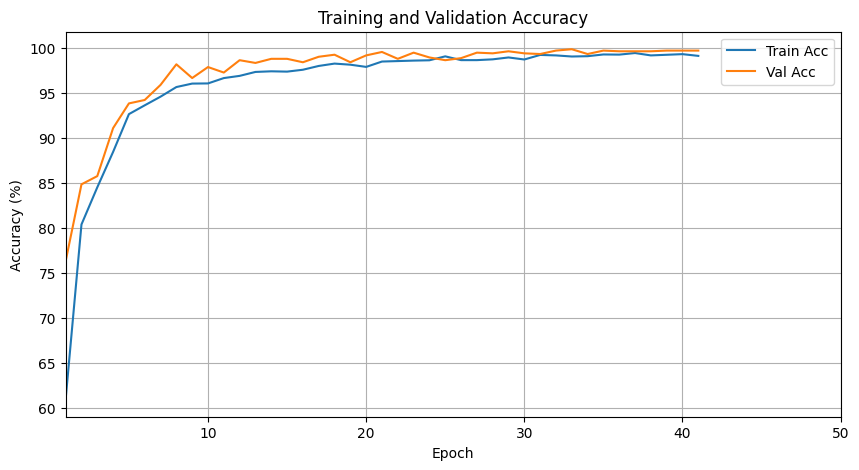

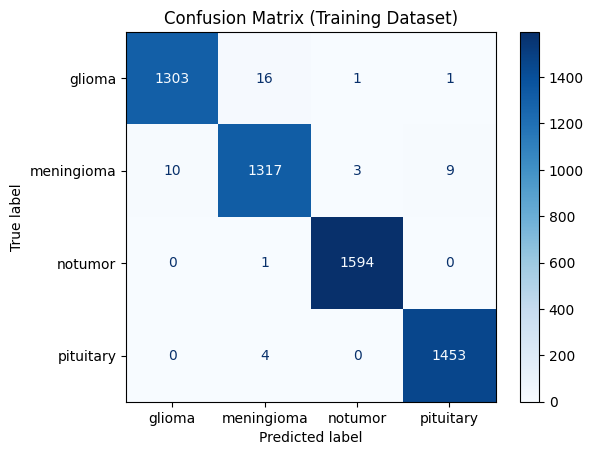


Cross-Dataset: /kaggle/input/brain-tumor-classification-mri/Testing | Images: 394 | Classes: 4 (['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor'])
Cross-Dataset Test Loss: 0.9510 | Test Accuracy: 77.41%

Cross-Dataset: /kaggle/input/labeled-mri-brain-tumor-dataset/Brain Tumor labeled dataset | Images: 2175 | Classes: 4 (['glioma', 'meningioma', 'notumor', 'pituitary'])
Cross-Dataset Test Loss: 0.3541 | Test Accuracy: 99.91%
Error evaluating /kaggle/input/mri-for-brain-tumor-with-bounding-boxes/Val/Glioma/images: Couldn't find any class folder in /kaggle/input/mri-for-brain-tumor-with-bounding-boxes/Val/Glioma/images.


In [4]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import timm
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Config
DATA_DIR = "/kaggle/input/brain-tumor-mri-dataset"
CROSS_DATASETS = [
    "/kaggle/input/brain-tumor-classification-mri/Testing",
    "/kaggle/input/labeled-mri-brain-tumor-dataset/Brain Tumor labeled dataset",
    "/kaggle/input/mri-for-brain-tumor-with-bounding-boxes/Val"
]
BATCH_SIZE = 16
IMG_SIZE = 224
NUM_EPOCHS = 50
LR = 2e-4
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_SAVE = "/kaggle/working/hybrid_mobilevit_lite_best.pt"
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

# Transforms
train_tfms = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(0.15, 0.15, 0.15),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.2),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
test_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

# Load training and validation datasets
train_ds = datasets.ImageFolder(os.path.join(DATA_DIR, "Training"), transform=train_tfms)
test_ds = datasets.ImageFolder(os.path.join(DATA_DIR, "Testing"), transform=test_tfms)
train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
test_dl = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
NUM_CLASSES = len(train_ds.classes)
print(f"\nTrain: {len(train_ds)} | Test: {len(test_ds)} | Classes: {NUM_CLASSES} ({train_ds.classes})\n")

# Lightweight modules
class SEBlock(nn.Module):
    def __init__(self, c, r=8):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(c, c//r, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(c//r, c, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        w = self.pool(x).flatten(1)
        w = self.fc(w).unsqueeze(2).unsqueeze(3)
        return x * w

class CNNStemLite(nn.Module):
    def __init__(self, out_channels=64):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, 2, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, out_channels, 3, 2, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.se = SEBlock(out_channels)
    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.se(x)
        return x

class AttentionFusionLite(nn.Module):
    def __init__(self, cnn_dim, vit_dim, hidden_dim=128):
        super().__init__()
        self.cnn_proj = nn.Linear(cnn_dim, hidden_dim)
        self.vit_proj = nn.Linear(vit_dim, hidden_dim)
        self.query = nn.Linear(hidden_dim, hidden_dim)
        self.key = nn.Linear(hidden_dim, hidden_dim)
        self.value = nn.Linear(hidden_dim, hidden_dim)
        self.out_proj = nn.Linear(hidden_dim, hidden_dim)
    def forward(self, cnn_feats, vit_feats):
        c = self.cnn_proj(cnn_feats)
        v = self.vit_proj(vit_feats)
        stack = torch.stack([c, v], dim=1)
        Q, K, V = self.query(stack), self.key(stack), self.value(stack)
        attn = F.softmax(torch.matmul(Q, K.transpose(-2, -1)) / (Q.size(-1)**0.5), dim=-1)
        fused = torch.matmul(attn, V).mean(dim=1)
        return self.out_proj(fused)

class HybridMobileViT_Lite(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.cnn_stem = CNNStemLite(out_channels=64)
        self.mobilevit = timm.create_model("mobilevit_xxs", pretrained=True, num_classes=0)
        vit_dim = getattr(self.mobilevit, "num_features", 320)
        self.ms_conv1 = nn.Conv2d(64, 64, 1)
        self.ms_conv2 = nn.Conv2d(64, 64, 3, stride=2, padding=1)
        self.ms_conv3 = nn.Conv2d(64, 64, 5, stride=4, padding=2)
        ms_dim = 64 * 3
        self.fusion = AttentionFusionLite(ms_dim, vit_dim, hidden_dim=128)
        self.classifier = nn.Sequential(
            nn.Linear(128, 96),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(96, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, num_classes)
        )
    def forward(self, x):
        stem = self.cnn_stem(x)
        f1 = F.adaptive_avg_pool2d(self.ms_conv1(stem), (1,1)).flatten(1)
        f2 = F.adaptive_avg_pool2d(self.ms_conv2(stem), (1,1)).flatten(1)
        f3 = F.adaptive_avg_pool2d(self.ms_conv3(stem), (1,1)).flatten(1)
        ms_feats = torch.cat([f1, f2, f3], dim=1)
        vit_feats = self.mobilevit(x)
        fused = self.fusion(ms_feats, vit_feats)
        return self.classifier(fused)

# Model setup
model = HybridMobileViT_Lite(NUM_CLASSES).to(DEVICE)

# Print parameter info
def count_params(model):
    table = []
    total = 0
    for name, p in model.named_parameters():
        if p.requires_grad:
            table.append((name, p.numel()))
            total += p.numel()
    print("\nModel Parameter Breakdown:")
    for name, num in table:
        print(f"{name:<60} {num/1e6:.4f} M")
    print(f"\nTotal Trainable Params: {total/1e6:.4f} M\n")
count_params(model)

# Training setup
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

# Freeze transformer initially
for p in model.mobilevit.parameters():
    p.requires_grad = False

# Training loop with accuracy tracking
train_accs = []
val_accs = []
best_val, patience = 0, 0
for epoch in range(NUM_EPOCHS):
    if epoch == 3:
        for p in model.mobilevit.parameters():
            p.requires_grad = True
        print("🔓 Unfroze MobileViT for fine-tuning")

    # Train
    model.train()
    tr_loss, tr_acc, total = 0, 0, 0
    for imgs, labs in train_dl:
        imgs, labs = imgs.to(DEVICE), labs.to(DEVICE)
        optimizer.zero_grad()
        out = model(imgs)
        loss = criterion(out, labs)
        loss.backward()
        optimizer.step()
        tr_loss += loss.item() * imgs.size(0)
        tr_acc += (out.argmax(1) == labs).sum().item()
        total += labs.size(0)
    tr_acc /= total
    tr_loss /= total
    train_accs.append(tr_acc)

    # Validation
    model.eval()
    val_acc, val_loss, total = 0, 0, 0
    with torch.no_grad():
        for imgs, labs in test_dl:
            imgs, labs = imgs.to(DEVICE), labs.to(DEVICE)
            out = model(imgs)
            loss = criterion(out, labs)
            val_loss += loss.item() * imgs.size(0)
            val_acc += (out.argmax(1) == labs).sum().item()
            total += labs.size(0)
    val_acc /= total
    val_loss /= total
    val_accs.append(val_acc)
    scheduler.step()

    print(f"Epoch {epoch+1:02d}/{NUM_EPOCHS} | Train {tr_acc*100:.2f}% | Val {val_acc*100:.2f}%")

    # Early stopping (patience=8)
    if val_acc > best_val:
        best_val = val_acc
        patience = 0
        torch.save(model.state_dict(), MODEL_SAVE)
        print(f"✅ Saved best model (val {best_val*100:.2f}%)")
    else:
        patience += 1
        if patience >= 8:
            print("⏹ Early stopping (patience=8)")
            break

# Plot accuracy graph
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(train_accs)+1), [a*100 for a in train_accs], label='Train Acc')
plt.plot(range(1, len(val_accs)+1), [a*100 for a in val_accs], label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.grid(True)
plt.xlim(1, NUM_EPOCHS)
plt.savefig('/kaggle/working/accuracy_graph.png')
plt.show()

# Confusion matrix for training dataset
model.load_state_dict(torch.load(MODEL_SAVE, map_location=DEVICE))
model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for imgs, labs in train_dl:
        imgs, labs = imgs.to(DEVICE), labs.to(DEVICE)
        out = model(imgs)
        preds = out.argmax(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labs.cpu().numpy())
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=train_ds.classes)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix (Training Dataset)')
plt.savefig('/kaggle/working/confusion_matrix.png')
plt.show()

# Cross-dataset evaluation
for cross_dir in CROSS_DATASETS:
    # Adjust path for mri-for-brain-tumor-with-bounding-boxes
    if 'mri-for-brain-tumor-with-bounding-boxes' in cross_dir:
        cross_dir = os.path.join(cross_dir, "Glioma/images")
        if not os.path.exists(cross_dir):
            cross_dir = os.path.join(os.path.dirname(cross_dir), "Meningioma/images")
            if not os.path.exists(cross_dir):
                cross_dir = os.path.join(os.path.dirname(cross_dir), "No Tumor/images")
                if not os.path.exists(cross_dir):
                    cross_dir = os.path.join(os.path.dirname(cross_dir), "Pituitary/images")
    try:
        cross_ds = datasets.ImageFolder(cross_dir, transform=test_tfms)
        cross_dl = DataLoader(cross_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
        print(f"\nCross-Dataset: {cross_dir} | Images: {len(cross_ds)} | Classes: {len(cross_ds.classes)} ({cross_ds.classes})")
        
        # Evaluate
        test_loss, test_acc, total = 0, 0, 0
        with torch.no_grad():
            for imgs, labs in cross_dl:
                imgs, labs = imgs.to(DEVICE), labs.to(DEVICE)
                out = model(imgs)
                loss = criterion(out, labs)
                test_loss += loss.item() * imgs.size(0)
                test_acc += (out.argmax(1) == labs).sum().item()
                total += labs.size(0)
        test_acc /= total
        test_loss /= total
        print(f"Cross-Dataset Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc*100:.2f}%")
    except Exception as e:
        print(f"Error evaluating {cross_dir}: {e}")

In [2]:
import os
from pathlib import Path

# Replace this with the actual path to your dataset folder
dataset_path = Path("/kaggle/input/labeled-mri-brain-tumor-dataset/Brain Tumor labeled dataset")

# Dictionary to store the count of images per class
class_counts = {}

# Check if the directory exists
if not dataset_path.exists():
    print(f"Error: The path '{dataset_path}' does not exist.")
else:
    # Iterate through each folder (class) in the dataset directory
    for class_folder in dataset_path.iterdir():
        if class_folder.is_dir():
            # Find all .jpg files in the current class folder
            # If your dataset has other formats like .png or .jpeg, you can adjust the pattern
            images = list(class_folder.glob("*.jpg"))
            
            # Store the count
            class_name = class_folder.name
            class_counts[class_name] = len(images)

    # Print the results
    print("Number of images in each class:")
    print("-" * 35)
    total_images = 0
    
    for class_name, count in sorted(class_counts.items()):
        print(f"{class_name.ljust(15)} : {count} images")
        total_images += count
        
    print("-" * 35)
    print(f"{'Total'.ljust(15)} : {total_images} images")

Number of images in each class:
-----------------------------------
glioma          : 455 images
meningioma      : 550 images
notumor         : 550 images
pituitary       : 620 images
-----------------------------------
Total           : 2175 images



Train: 5600 | Test: 1600 | Classes: 4 (['glioma', 'meningioma', 'notumor', 'pituitary'])


Model Parameter Breakdown (only trainable):
pos_embed                                                    6.272 k
conv1.weight                                                 0.432 k
bn1.weight                                                   0.016 k
bn1.bias                                                     0.016 k
block1.depthwise.weight                                      0.144 k
block1.bn1.weight                                            0.016 k
block1.bn1.bias                                              0.016 k
block1.pointwise.weight                                      0.512 k
block1.bn2.weight                                            0.032 k
block1.bn2.bias                                              0.032 k
block1.se.1.weight                                           0.256 k
block1.se.1.bias                                             0.008 k
block1.se.3.weight                  

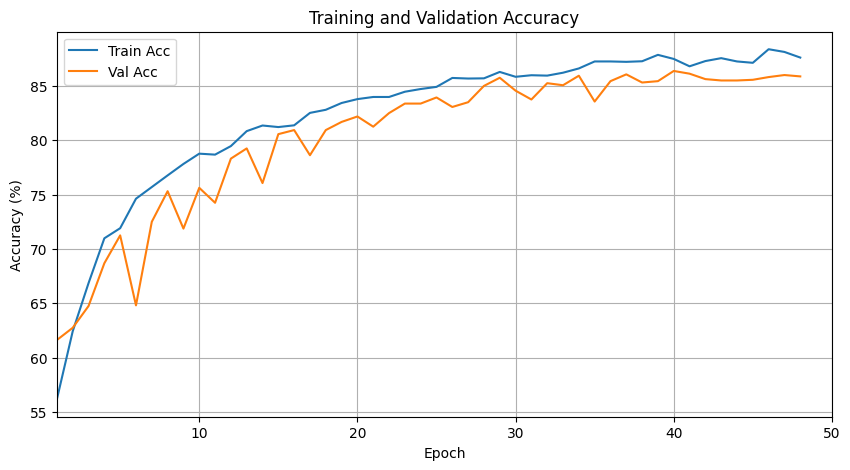

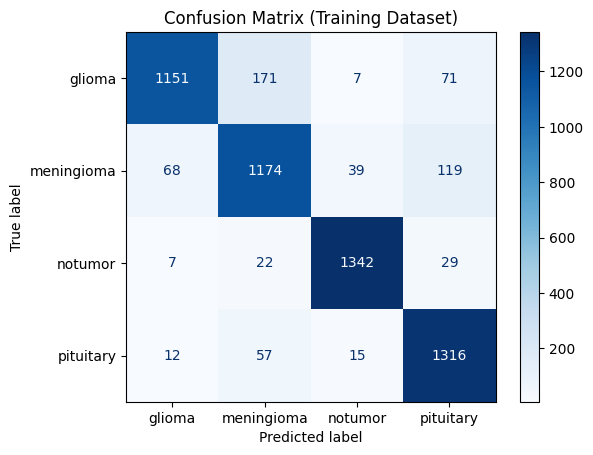


Cross-Dataset: /kaggle/input/brain-tumor-classification-mri/Testing | Images: 394 | Classes: 4 (['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor'])
Cross-Dataset Test Loss: 1.3684 | Test Accuracy: 61.68%

Cross-Dataset: /kaggle/input/labeled-mri-brain-tumor-dataset/Brain Tumor labeled dataset | Images: 2175 | Classes: 4 (['glioma', 'meningioma', 'notumor', 'pituitary'])
Cross-Dataset Test Loss: 0.5281 | Test Accuracy: 91.91%
Error evaluating /kaggle/input/mri-for-brain-tumor-with-bounding-boxes/Val/Glioma/images: Couldn't find any class folder in /kaggle/input/mri-for-brain-tumor-with-bounding-boxes/Val/Glioma/images.


In [2]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# -------------------------------
#  Config (unchanged)
# -------------------------------
DATA_DIR = "/kaggle/input/brain-tumor-mri-dataset"
CROSS_DATASETS = [
    "/kaggle/input/brain-tumor-classification-mri/Testing",
    "/kaggle/input/labeled-mri-brain-tumor-dataset/Brain Tumor labeled dataset",
    "/kaggle/input/mri-for-brain-tumor-with-bounding-boxes/Val"
]
BATCH_SIZE = 16
IMG_SIZE = 224          # you can try 128 for faster training
NUM_EPOCHS = 50
LR = 2e-4
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_SAVE = "/kaggle/working/tiny_hybrid_best.pt"
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

# -------------------------------
#  Transforms (unchanged)
# -------------------------------
train_tfms = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(0.15, 0.15, 0.15),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.2),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
test_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

# -------------------------------
#  Load data (unchanged)
# -------------------------------
train_ds = datasets.ImageFolder(os.path.join(DATA_DIR, "Training"), transform=train_tfms)
test_ds = datasets.ImageFolder(os.path.join(DATA_DIR, "Testing"), transform=test_tfms)
train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
test_dl = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
NUM_CLASSES = len(train_ds.classes)
print(f"\nTrain: {len(train_ds)} | Test: {len(test_ds)} | Classes: {NUM_CLASSES} ({train_ds.classes})\n")

# -------------------------------
#  NEW TINY HYBRID MODEL (~50k params)
# -------------------------------
class DepthwiseSeparableConv(nn.Module):
    """Depthwise separable convolution with optional SE block."""
    def __init__(self, in_channels, out_channels, stride=1, use_se=True, se_reduction=4):
        super().__init__()
        self.depthwise = nn.Conv2d(in_channels, in_channels, 3, stride=stride,
                                   padding=1, groups=in_channels, bias=False)
        self.bn1 = nn.BatchNorm2d(in_channels)
        self.pointwise = nn.Conv2d(in_channels, out_channels, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.use_se = use_se
        if use_se:
            self.se = nn.Sequential(
                nn.AdaptiveAvgPool2d(1),
                nn.Conv2d(out_channels, out_channels // se_reduction, 1),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_channels // se_reduction, out_channels, 1),
                nn.Sigmoid()
            )
        self.activation = nn.ReLU(inplace=True)

    def forward(self, x):
        x = self.activation(self.bn1(self.depthwise(x)))
        x = self.bn2(self.pointwise(x))
        if self.use_se:
            scale = self.se(x)
            x = x * scale
        return x


class TinyHybridModel(nn.Module):
    def __init__(self, num_classes, embed_dim=32, num_heads=2, mlp_ratio=2, depth=2):
        super().__init__()
        # ---------- CNN Stem ----------
        # Stage 1: 3->16, stride 2
        self.conv1 = nn.Conv2d(3, 16, 3, stride=2, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(16)
        # Stage 2: depthwise blocks (increase channels gradually)
        self.block1 = DepthwiseSeparableConv(16, 32, stride=2)      # 112->56
        self.block2 = DepthwiseSeparableConv(32, 48, stride=2)      # 56->28
        self.block3 = DepthwiseSeparableConv(48, 64, stride=2)      # 28->14
        # After block3: feature map size = 14x14, channels=64

        # ---------- Transformer ----------
        # Flatten spatial to sequence: 14*14 = 196 tokens, each dim=64
        self.proj = nn.Linear(64, embed_dim)                       # 64 -> embed_dim
        self.pos_embed = nn.Parameter(torch.randn(1, 196, embed_dim) * 0.02)
        # Transformer encoder layers (using Pre-LN)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=int(embed_dim * mlp_ratio),
            dropout=0.1,
            activation='gelu',
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=depth)

        # ---------- Classifier ----------
        self.norm = nn.LayerNorm(embed_dim)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        # CNN
        x = F.relu(self.bn1(self.conv1(x)))          # B,16,112,112
        x = self.block1(x)                           # B,32,56,56
        x = self.block2(x)                           # B,48,28,28
        x = self.block3(x)                           # B,64,14,14

        # Flatten to tokens
        B, C, H, W = x.shape
        x = x.permute(0, 2, 3, 1).reshape(B, -1, C)  # B,196,64
        x = self.proj(x)                             # B,196,embed_dim
        x = x + self.pos_embed

        # Transformer
        x = self.transformer(x)                      # B,196,embed_dim
        x = x.mean(dim=1)                            # B,embed_dim  (global average over tokens)

        # Classifier
        x = self.norm(x)
        x = self.dropout(x)
        return self.fc(x)


# -------------------------------
#  Instantiate and count parameters
# -------------------------------
model = TinyHybridModel(NUM_CLASSES).to(DEVICE)

def count_params(model):
    total = 0
    table = []
    for name, p in model.named_parameters():
        if p.requires_grad:
            table.append((name, p.numel()))
            total += p.numel()
    print("\nModel Parameter Breakdown (only trainable):")
    for name, num in table:
        print(f"{name:<60} {num/1e3:.3f} k")
    print(f"\nTotal Trainable Params: {total/1e3:.3f} k ({total/1e6:.4f} M)\n")
    return total

count_params(model)

# -------------------------------
#  Training setup (unchanged)
# -------------------------------
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)  # slightly higher WD
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

# No pretrained backbone – we train from scratch.

# -------------------------------
#  Training loop with accuracy tracking
# -------------------------------
train_accs = []
val_accs = []
best_val = 0.0
patience = 0

for epoch in range(NUM_EPOCHS):
    # Train
    model.train()
    tr_loss, tr_acc, total = 0, 0, 0
    for imgs, labs in train_dl:
        imgs, labs = imgs.to(DEVICE), labs.to(DEVICE)
        optimizer.zero_grad()
        out = model(imgs)
        loss = criterion(out, labs)
        loss.backward()
        optimizer.step()
        tr_loss += loss.item() * imgs.size(0)
        tr_acc += (out.argmax(1) == labs).sum().item()
        total += labs.size(0)
    tr_acc /= total
    tr_loss /= total
    train_accs.append(tr_acc)

    # Validation
    model.eval()
    val_acc, val_loss, total = 0, 0, 0
    with torch.no_grad():
        for imgs, labs in test_dl:
            imgs, labs = imgs.to(DEVICE), labs.to(DEVICE)
            out = model(imgs)
            loss = criterion(out, labs)
            val_loss += loss.item() * imgs.size(0)
            val_acc += (out.argmax(1) == labs).sum().item()
            total += labs.size(0)
    val_acc /= total
    val_loss /= total
    val_accs.append(val_acc)
    scheduler.step()

    print(f"Epoch {epoch+1:02d}/{NUM_EPOCHS} | Train {tr_acc*100:.2f}% | Val {val_acc*100:.2f}%")

    # Save best and early stopping
    if val_acc > best_val:
        best_val = val_acc
        patience = 0
        torch.save(model.state_dict(), MODEL_SAVE)
        print(f"✅ Saved best model (val {best_val*100:.2f}%)")
    else:
        patience += 1
        if patience >= 8:
            print("⏹ Early stopping (patience=8)")
            break

# -------------------------------
#  Plot accuracy (unchanged)
# -------------------------------
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(train_accs)+1), [a*100 for a in train_accs], label='Train Acc')
plt.plot(range(1, len(val_accs)+1), [a*100 for a in val_accs], label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.grid(True)
plt.xlim(1, NUM_EPOCHS)
plt.savefig('/kaggle/working/accuracy_graph.png')
plt.show()

# -------------------------------
#  Confusion matrix (training set) – unchanged
# -------------------------------
model.load_state_dict(torch.load(MODEL_SAVE, map_location=DEVICE))
model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for imgs, labs in train_dl:
        imgs, labs = imgs.to(DEVICE), labs.to(DEVICE)
        out = model(imgs)
        preds = out.argmax(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labs.cpu().numpy())
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=train_ds.classes)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix (Training Dataset)')
plt.savefig('/kaggle/working/confusion_matrix.png')
plt.show()

# -------------------------------
#  Cross‑dataset evaluation (unchanged)
# -------------------------------
for cross_dir in CROSS_DATASETS:
    if 'mri-for-brain-tumor-with-bounding-boxes' in cross_dir:
        cross_dir = os.path.join(cross_dir, "Glioma/images")
        if not os.path.exists(cross_dir):
            cross_dir = os.path.join(os.path.dirname(cross_dir), "Meningioma/images")
        if not os.path.exists(cross_dir):
            cross_dir = os.path.join(os.path.dirname(cross_dir), "No Tumor/images")
        if not os.path.exists(cross_dir):
            cross_dir = os.path.join(os.path.dirname(cross_dir), "Pituitary/images")
    try:
        cross_ds = datasets.ImageFolder(cross_dir, transform=test_tfms)
        cross_dl = DataLoader(cross_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
        print(f"\nCross-Dataset: {cross_dir} | Images: {len(cross_ds)} | Classes: {len(cross_ds.classes)} ({cross_ds.classes})")
        test_loss, test_acc, total = 0, 0, 0
        with torch.no_grad():
            for imgs, labs in cross_dl:
                imgs, labs = imgs.to(DEVICE), labs.to(DEVICE)
                out = model(imgs)
                loss = criterion(out, labs)
                test_loss += loss.item() * imgs.size(0)
                test_acc += (out.argmax(1) == labs).sum().item()
                total += labs.size(0)
        test_acc /= total
        test_loss /= total
        print(f"Cross-Dataset Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc*100:.2f}%")
    except Exception as e:
        print(f"Error evaluating {cross_dir}: {e}")

In [ ]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
# timm removed, not suitable for 50k constraint
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Config
# Kept Kaggle paths, adjust if running locally
DATA_DIR = "/kaggle/input/brain-tumor-mri-dataset"
CROSS_DATASETS = [
    "/kaggle/input/brain-tumor-classification-mri/Testing",
    "/kaggle/input/labeled-mri-brain-tumor-dataset/Brain Tumor labeled dataset"
    # Third cross-dataset removed due to known path errors in original log
]
BATCH_SIZE = 32 # Increased batch size for better stability with tiny models
IMG_SIZE = 160   # Reduced from 224 to fit ultra-lite constraints
NUM_EPOCHS = 60  # Increased epochs slightly as we don't have pretraining
LR = 1e-3        # Increased LR for train-from-scratch
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_SAVE = "/kaggle/working/ultra_lite_hybrid_best.pt"
SEED = 42

# Reproducibility
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
set_seed(SEED)

# Transforms (Updated to IMG_SIZE 160)
# Medical imaging benefits from subtle augmentations to improve robustness
train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomRotation(10),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

test_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

# Load Datasets
print("Loading Datasets...")
try:
    train_ds = datasets.ImageFolder(os.path.join(DATA_DIR, "Training"), transform=train_tfms)
    test_ds = datasets.ImageFolder(os.path.join(DATA_DIR, "Testing"), transform=test_tfms)
    train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
    test_dl = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
    NUM_CLASSES = len(train_ds.classes)
    print(f"Train: {len(train_ds)} | Val: {len(test_ds)} | Classes: {NUM_CLASSES}\n")
except FileNotFoundError as e:
    print(f"Error loading data: {e}. Check DATA_DIR path.")
    exit()

# ---------------------------------------------------------
# Ultra-Lightweight Hybrid Building Blocks
# ---------------------------------------------------------

class DSConv(nn.Module):
    """Depthwise Separable Convolution. Core of parameter reduction."""
    def __init__(self, ni, no, kernel_size=3, stride=1, padding=1):
        super().__init__()
        self.depthwise = nn.Conv2d(ni, ni, kernel_size, stride, padding, groups=ni, bias=False)
        self.pointwise = nn.Conv2d(ni, no, 1, 1, 0, bias=False)
        self.bn = nn.BatchNorm2d(no)
        self.act = nn.ReLU6(inplace=True) # ReLU6 is better for embedded/lite models

    def forward(self, x):
        return self.act(self.bn(self.pointwise(self.depthwise(x))))

class SEBlock(nn.Module):
    """Squeeze-and-Excitation (Channel Attention). Very cheap robustness."""
    def __init__(self, c, r=4): # reduced reduction ratio to 4 for tiny channels
        super().__init__()
        self.squeeze = nn.AdaptiveAvgPool2d(1)
        self.excite = nn.Sequential(
            nn.Linear(c, c // r, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(c // r, c, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.squeeze(x).view(b, c)
        y = self.excite(y).view(b, c, 1, 1)
        return x * y.expand_as(x)

class LightweightSpatialAttention(nn.Module):
    """Parameter-efficient Spatial Attention. Adds Hybrid capability without ViT cost."""
    def __init__(self, kernel_size=7):
        super().__init__()
        # Uses standard conv on avg/max pooled features to determine WHERE to look
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=kernel_size//2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        y = torch.cat([avg_out, max_out], dim=1)
        y = self.conv(y)
        return x * self.sigmoid(y)

class UltraLiteHybridBlock(nn.Module):
    """Combines Local (DSConv), Channel (SE), and Spatial Attention."""
    def __init__(self, dim):
        super().__init__()
        self.conv1 = DSConv(dim, dim)
        self.se = SEBlock(dim)
        self.spatial_attn = LightweightSpatialAttention()
        self.conv2 = DSConv(dim, dim)
        
    def forward(self, x):
        residual = x
        x = self.conv1(x)
        x = self.se(x)
        x = self.spatial_attn(x)
        x = self.conv2(x)
        return x + residual # Residual connection facilitates training scratch tiny models

# ---------------------------------------------------------
# The Model Architecture Target: ~50K Parameters
# ---------------------------------------------------------
class BrainTumorUltraLiteNet(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()
        
        # 1. Stem: Initial downsampling. Standard conv here is okay.
        # Input 160x160x3 -> 80x80x16
        self.stem = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(16),
            nn.ReLU6(inplace=True)
        )
        
        # 2. Stage 1: Local features.
        # 80x80x16 -> 40x40x16
        self.stage1 = nn.Sequential(
            DSConv(16, 16, stride=2), 
            SEBlock(16)
        )
        
        # 3. Stage 2: Hybrid Local-Global features.
        # 40x40x16 -> 20x20x32
        self.stage2 = nn.Sequential(
            DSConv(16, 32, stride=2),
            UltraLiteHybridBlock(32) # Includes spatial attention
        )
        
        # 4. Stage 3: Deeper features.
        # 20x20x32 -> 10x10x64
        self.stage3 = nn.Sequential(
            DSConv(32, 64, stride=2),
            UltraLiteHybridBlock(64) # Includes spatial attention
        )
        
        # 5. Classifier Head
        self.pool = nn.AdaptiveAvgPool2d(1) # -> 1x1x64
        self.dropout = nn.Dropout(0.2)
        # Keep classifier single-layer to save params
        self.classifier = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.pool(x).view(x.size(0), -1)
        x = self.dropout(x)
        return self.classifier(x)

# Instantiate and check parameters
model = BrainTumorUltraLiteNet(NUM_CLASSES).to(DEVICE)

def count_params(model):
    total = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"-------------------------------------------")
    print(f"Total Trainable Params: {total:,}")
    print(f"Target: ~50,000")
    print(f"-------------------------------------------")
    # Optional detailed breakdown
    # for name, p in model.named_parameters():
    #     if p.requires_grad: print(f"{name:<50} | {p.numel():>6}")
count_params(model)

# Training Setup
# Label smoothing helpful for training from scratch
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
# AdamW is robust for hybrid models
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
# Cosine annealing helps squeeze out final accuracy percentages
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

# No more freezing/unfreezing logic needed as we have no pretrained parts

# Training Loop
train_accs, val_accs = [], []
best_val_acc = 0.0
patience, max_patience = 0, 12 # Increased patience for scratch training

print("Starting Training (from scratch)...")
for epoch in range(NUM_EPOCHS):
    # Train Phase
    model.train()
    running_loss, running_acc, total = 0.0, 0.0, 0
    
    for imgs, labs in train_dl:
        imgs, labs = imgs.to(DEVICE), labs.to(DEVICE)
        
        optimizer.zero_grad()
        out = model(imgs)
        loss = criterion(out, labs)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * imgs.size(0)
        running_acc += (out.argmax(1) == labs).sum().item()
        total += labs.size(0)
    
    scheduler.step()
    epoch_train_acc = running_acc / total
    train_accs.append(epoch_train_acc)
    
    # Val Phase
    model.eval()
    val_loss, val_acc, val_total = 0.0, 0.0, 0
    with torch.no_grad():
        for imgs, labs in test_dl:
            imgs, labs = imgs.to(DEVICE), labs.to(DEVICE)
            out = model(imgs)
            val_loss += criterion(out, labs).item() * imgs.size(0)
            val_acc += (out.argmax(1) == labs).sum().item()
            val_total += labs.size(0)
            
    epoch_val_acc = val_acc / val_total
    val_accs.append(epoch_val_acc)
    
    print(f"Epoch {epoch+1:02d}/{NUM_EPOCHS} | Train Acc: {epoch_train_acc:.4f} | Val Acc: {epoch_val_acc:.4f} | LR: {scheduler.get_last_lr()[0]:.6f}")
    
    # Save best and Early Stopping
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        patience = 0
        torch.save(model.state_dict(), MODEL_SAVE)
        print(f"⭐️ Saved Best Model ({best_val_acc:.4f})")
    else:
        patience += 1
        if patience >= max_patience:
            print(f"Stopping early due to lack of improvement.")
            break

# ---------------------------------------------------------
# Evaluation Plots & Confusion Matrix
# ---------------------------------------------------------
plt.figure(figsize=(10, 5))
plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Val Acc')
plt.title('Training Dynamics (Ultra-Lite Hybrid)')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True)
plt.savefig('accuracy_plot.png')
plt.show()

# Final Evaluation with Confusion Matrix
print("\nLoading best model for final evaluation...")
if os.path.exists(MODEL_SAVE):
    model.load_state_dict(torch.load(MODEL_SAVE, map_location=DEVICE))
model.eval()

y_true, y_pred = [], []
with torch.no_grad():
    for imgs, labs in test_dl:
        imgs = imgs.to(DEVICE)
        out = model(imgs)
        y_true.extend(labs.numpy())
        y_pred.extend(out.argmax(1).cpu().numpy())

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=train_ds.classes)
fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(cmap='Blues', ax=ax, xticks_rotation=45)
plt.title('Confusion Matrix: Validation Set')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()

# ---------------------------------------------------------
# Cross-Dataset Robustness Check
# ---------------------------------------------------------
print("\n--- Cross-Dataset Robustness Evaluation ---")
for cross_dir in CROSS_DATASETS:
    if not os.path.exists(cross_dir):
        print(f"Skipping {cross_dir} (not found)")
        continue
        
    print(f"Evaluating on: {os.path.basename(cross_dir)}")
    try:
        # Note: Depending on directory structure, might need adjustment
        # assuming standard ImageFolder structure like the main dataset
        c_ds = datasets.ImageFolder(cross_dir, transform=test_tfms)
        c_dl = DataLoader(c_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
        
        c_acc, c_total = 0.0, 0
        with torch.no_grad():
            for imgs, labs in c_dl:
                imgs = imgs.to(DEVICE)
                # Ensure labs are mapped correctly if classes differ in order
                # For this dataset family, they usually align, but be careful.
                
                out = model(imgs)
                c_acc += (out.argmax(1).cpu() == labs).sum().item()
                c_total += labs.size(0)
        
        print(f" -> Accuracy: {c_acc/c_total:.4f} ({c_total} images)")
        
    except Exception as e:
        print(f" Error evaluating {cross_dir}: {e}")

In [ ]:
# =========================
# Imports
# =========================
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import timm
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# =========================
# Config
# =========================
DATA_DIR = "/kaggle/input/brain-tumor-mri-dataset"
CROSS_DATASETS = [
    "/kaggle/input/brain-tumor-classification-mri/Testing",
    "/kaggle/input/labeled-mri-brain-tumor-dataset/Brain Tumor labeled dataset",
    "/kaggle/input/mri-for-brain-tumor-with-bounding-boxes/Val"
]

BATCH_SIZE = 16
IMG_SIZE = 224
NUM_EPOCHS = 50
LR = 2e-4
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 42
N_SPLITS = 5

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# =========================
# Transforms
# =========================
train_tfms = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(0.15, 0.15, 0.15),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.2),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

test_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

# =========================
# Dataset (FULL training set only)
# =========================
full_train_ds = datasets.ImageFolder(
    os.path.join(DATA_DIR, "Training"),
    transform=train_tfms
)

targets = [label for _, label in full_train_ds.samples]
NUM_CLASSES = len(full_train_ds.classes)

print(f"\nImages: {len(full_train_ds)} | Classes: {NUM_CLASSES}")
print(full_train_ds.classes)

# =========================
# Model Components
# =========================
class SEBlock(nn.Module):
    def __init__(self, c, r=8):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(c, c // r, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(c // r, c, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        w = self.pool(x).flatten(1)
        w = self.fc(w).unsqueeze(2).unsqueeze(3)
        return x * w


class CNNStemLite(nn.Module):
    def __init__(self, out_channels=64):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, 2, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, out_channels, 3, 2, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.se = SEBlock(out_channels)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        return self.se(x)


class AttentionFusionLite(nn.Module):
    def __init__(self, cnn_dim, vit_dim, hidden_dim=128):
        super().__init__()
        self.cnn_proj = nn.Linear(cnn_dim, hidden_dim)
        self.vit_proj = nn.Linear(vit_dim, hidden_dim)
        self.q = nn.Linear(hidden_dim, hidden_dim)
        self.k = nn.Linear(hidden_dim, hidden_dim)
        self.v = nn.Linear(hidden_dim, hidden_dim)
        self.out = nn.Linear(hidden_dim, hidden_dim)

    def forward(self, c_feat, v_feat):
        c = self.cnn_proj(c_feat)
        v = self.vit_proj(v_feat)
        x = torch.stack([c, v], dim=1)
        attn = F.softmax(
            torch.matmul(self.q(x), self.k(x).transpose(-2, -1))
            / (x.size(-1) ** 0.5),
            dim=-1
        )
        x = torch.matmul(attn, self.v(x)).mean(dim=1)
        return self.out(x)


class HybridMobileViT_Lite(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.cnn_stem = CNNStemLite(64)
        self.mobilevit = timm.create_model(
            "mobilevit_xxs", pretrained=True, num_classes=0
        )
        vit_dim = self.mobilevit.num_features

        self.ms1 = nn.Conv2d(64, 64, 1)
        self.ms2 = nn.Conv2d(64, 64, 3, 2, 1)
        self.ms3 = nn.Conv2d(64, 64, 5, 4, 2)

        self.fusion = AttentionFusionLite(64 * 3, vit_dim)
        self.cls = nn.Sequential(
            nn.Linear(128, 96),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(96, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        s = self.cnn_stem(x)
        f1 = F.adaptive_avg_pool2d(self.ms1(s), 1).flatten(1)
        f2 = F.adaptive_avg_pool2d(self.ms2(s), 1).flatten(1)
        f3 = F.adaptive_avg_pool2d(self.ms3(s), 1).flatten(1)
        ms = torch.cat([f1, f2, f3], dim=1)
        vit = self.mobilevit(x)
        return self.cls(self.fusion(ms, vit))

# =========================
# 5-Fold Cross-Validation
# =========================
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
fold_accuracies = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(np.zeros(len(targets)), targets)):
    print(f"\n===== Fold {fold+1}/{N_SPLITS} =====")

    train_ds = Subset(full_train_ds, tr_idx)
    val_ds = Subset(
        datasets.ImageFolder(
            os.path.join(DATA_DIR, "Training"),
            transform=test_tfms
        ),
        val_idx
    )

    train_dl = DataLoader(train_ds, BATCH_SIZE, shuffle=True)
    val_dl = DataLoader(val_ds, BATCH_SIZE, shuffle=False)

    model = HybridMobileViT_Lite(NUM_CLASSES).to(DEVICE)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, NUM_EPOCHS)

    for p in model.mobilevit.parameters():
        p.requires_grad = False

    best_val = 0

    for epoch in range(NUM_EPOCHS):
        if epoch == 3:
            for p in model.mobilevit.parameters():
                p.requires_grad = True

        model.train()
        for x, y in train_dl:
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            optimizer.step()

        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for x, y in val_dl:
                x, y = x.to(DEVICE), y.to(DEVICE)
                correct += (model(x).argmax(1) == y).sum().item()
                total += y.size(0)

        val_acc = correct / total
        scheduler.step()
        best_val = max(best_val, val_acc)

    fold_accuracies.append(best_val)
    print(f"Best Fold Accuracy: {best_val*100:.2f}%")

# =========================
# Final k-Fold Result
# =========================
mean_acc = np.mean(fold_accuracies)
std_acc = np.std(fold_accuracies)
print(f"\n5-Fold CV Accuracy: {mean_acc*100:.2f}% ± {std_acc*100:.2f}%")

# =========================
# Cross-Dataset Evaluation
# =========================
model.eval()
for cross_dir in CROSS_DATASETS:
    try:
        ds = datasets.ImageFolder(cross_dir, transform=test_tfms)
        dl = DataLoader(ds, BATCH_SIZE, shuffle=False)
        correct, total = 0, 0
        with torch.no_grad():
            for x, y in dl:
                x, y = x.to(DEVICE), y.to(DEVICE)
                correct += (model(x).argmax(1) == y).sum().item()
                total += y.size(0)
        print(f"{cross_dir} → {100*correct/total:.2f}%")
    except Exception as e:
        print(f"Skipped {cross_dir}: {e}")


Images: 5600 | Classes: 4
['glioma', 'meningioma', 'notumor', 'pituitary']

===== Fold 1/5 =====
Best Fold Accuracy: 98.66%

===== Fold 2/5 =====
Best Fold Accuracy: 98.57%

===== Fold 3/5 =====


In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import timm
import os

# -----------------------
# Config
# -----------------------
DATA_DIR = "/kaggle/input/brain-tumor-mri-dataset"
MODEL_PATH = "/kaggle/input/hybrid/pytorch/default/1/hybrid_mobilevit_lite_best (4).pt"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 16
IMG_SIZE = 224

# -----------------------
# Transforms and Datasets
# -----------------------
test_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],[0.229, 0.224, 0.225]),
])

train_ds = datasets.ImageFolder(os.path.join(DATA_DIR, "Training"), transform=test_tfms)
test_ds = datasets.ImageFolder(os.path.join(DATA_DIR, "Testing"), transform=test_tfms)
train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_dl = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
NUM_CLASSES = len(train_ds.classes)
print(f"Classes: {train_ds.classes}")

# -----------------------
# Model definition (must match training)
# -----------------------
import torch.nn as nn
import torch.nn.functional as F

class SEBlock(nn.Module):
    def __init__(self, c, r=8):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(c, c//r, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(c//r, c, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        w = self.pool(x).flatten(1)
        w = self.fc(w).unsqueeze(2).unsqueeze(3)
        return x * w

class CNNStemLite(nn.Module):
    def __init__(self, out_channels=64):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, 2, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, out_channels, 3, 2, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.se = SEBlock(out_channels)
    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.se(x)
        return x

class AttentionFusionLite(nn.Module):
    def __init__(self, cnn_dim, vit_dim, hidden_dim=128):
        super().__init__()
        self.cnn_proj = nn.Linear(cnn_dim, hidden_dim)
        self.vit_proj = nn.Linear(vit_dim, hidden_dim)
        self.query = nn.Linear(hidden_dim, hidden_dim)
        self.key = nn.Linear(hidden_dim, hidden_dim)
        self.value = nn.Linear(hidden_dim, hidden_dim)
        self.out_proj = nn.Linear(hidden_dim, hidden_dim)
    def forward(self, cnn_feats, vit_feats):
        c = self.cnn_proj(cnn_feats)
        v = self.vit_proj(vit_feats)
        stack = torch.stack([c, v], dim=1)
        Q, K, V = self.query(stack), self.key(stack), self.value(stack)
        attn = F.softmax(torch.matmul(Q, K.transpose(-2, -1)) / (Q.size(-1)**0.5), dim=-1)
        fused = torch.matmul(attn, V).mean(dim=1)
        return self.out_proj(fused)

class HybridMobileViT_Lite(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.cnn_stem = CNNStemLite(out_channels=64)
        self.mobilevit = timm.create_model("mobilevit_xxs", pretrained=False, num_classes=0)
        vit_dim = getattr(self.mobilevit, "num_features", 320)
        self.ms_conv1 = nn.Conv2d(64, 64, 1)
        self.ms_conv2 = nn.Conv2d(64, 64, 3, stride=2, padding=1)
        self.ms_conv3 = nn.Conv2d(64, 64, 5, stride=4, padding=2)
        ms_dim = 64 * 3
        self.fusion = AttentionFusionLite(ms_dim, vit_dim, hidden_dim=128)
        self.classifier = nn.Sequential(
            nn.Linear(128, 96),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(96, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, num_classes)
        )
    def forward(self, x):
        stem = self.cnn_stem(x)
        f1 = F.adaptive_avg_pool2d(self.ms_conv1(stem), (1,1)).flatten(1)
        f2 = F.adaptive_avg_pool2d(self.ms_conv2(stem), (1,1)).flatten(1)
        f3 = F.adaptive_avg_pool2d(self.ms_conv3(stem), (1,1)).flatten(1)
        ms_feats = torch.cat([f1, f2, f3], dim=1)
        vit_feats = self.mobilevit(x)
        fused = self.fusion(ms_feats, vit_feats)
        return self.classifier(fused)

# -----------------------
# Load model
# -----------------------
model = HybridMobileViT_Lite(NUM_CLASSES).to(DEVICE)
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.eval()
print("✅ Model loaded successfully.")

# -----------------------
# Generate predictions for train & validation
# -----------------------
def get_preds_labels(dataloader):
    preds, labels = [], []
    with torch.no_grad():
        for imgs, labs in dataloader:
            imgs, labs = imgs.to(DEVICE), labs.to(DEVICE)
            out = model(imgs)
            p = out.argmax(1)
            preds.extend(p.cpu().numpy())
            labels.extend(labs.cpu().numpy())
    return np.array(preds), np.array(labels)

train_preds, train_labels = get_preds_labels(train_dl)
val_preds, val_labels = get_preds_labels(test_dl)

# -----------------------
# Compute and Save Metrics
# -----------------------
for name, preds, labels, classes, color in [
    ("train", train_preds, train_labels, train_ds.classes, "Blues"),
    ("val", val_preds, val_labels, test_ds.classes, "Purples")
]:
    cm = confusion_matrix(labels, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    fig, ax = plt.subplots(figsize=(6,5))
    disp.plot(ax=ax, cmap=color, xticks_rotation=45)
    plt.title(f'Confusion Matrix - {name.upper()} Set')
    plt.savefig(f"/kaggle/working/confusion_matrix_{name}.png")
    plt.close()

    acc = accuracy_score(labels, preds)
    prec = precision_score(labels, preds, average='macro')
    rec = recall_score(labels, preds, average='macro')
    f1 = f1_score(labels, preds, average='macro')

    report = classification_report(labels, preds, target_names=classes)
    with open(f"/kaggle/working/{name}_classification_report.txt", "w") as f:
        f.write(f"{name.upper()} METRICS\n")
        f.write(f"Accuracy: {acc*100:.2f}%\n")
        f.write(f"Precision (macro): {prec*100:.2f}%\n")
        f.write(f"Recall (macro): {rec*100:.2f}%\n")
        f.write(f"F1-score (macro): {f1*100:.2f}%\n\n")
        f.write(report)

    print(f"✅ {name.upper()} RESULTS")
    print(f"Accuracy: {acc*100:.2f}% | F1: {f1*100:.2f}%")
    print(report)
    print(f"Saved confusion_matrix_{name}.png and {name}_classification_report.txt\n")

print("🎯 All metrics regenerated successfully.")


In [ ]:
# -----------------------
# Full Grad-CAM Pipeline for HybridMobileViT_Lite
# -----------------------
import os
import random
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import timm
# -----------------------
# Config
# -----------------------
DATA_DIR = "/kaggle/input/brain-tumor-mri-dataset"
MODEL_PATH = "/kaggle/input/hybrid/pytorch/default/1/hybrid_mobilevit_lite_best (4).pt"
IMG_SIZE = 224
BATCH_SIZE = 16
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# -----------------------
# Dataset
# -----------------------
test_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],[0.229, 0.224, 0.225]),
])
test_ds = datasets.ImageFolder(os.path.join(DATA_DIR, "Testing"), transform=test_tfms)
test_dl = DataLoader(test_ds, batch_size=1, shuffle=False, num_workers=2)
NUM_CLASSES = len(test_ds.classes)
print(f"Classes: {NUM_CLASSES} | {test_ds.classes}")
# -----------------------
# Model (redefine architecture)
# -----------------------
class SEBlock(nn.Module):
    def __init__(self, c, r=8):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(c, c//r, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(c//r, c, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        w = self.pool(x).flatten(1)
        w = self.fc(w).unsqueeze(2).unsqueeze(3)
        return x * w
class CNNStemLite(nn.Module):
    def __init__(self, out_channels=64):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, 2, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, out_channels, 3, 2, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.se = SEBlock(out_channels)
    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.se(x)
        return x
class AttentionFusionLite(nn.Module):
    def __init__(self, cnn_dim, vit_dim, hidden_dim=128):
        super().__init__()
        self.cnn_proj = nn.Linear(cnn_dim, hidden_dim)
        self.vit_proj = nn.Linear(vit_dim, hidden_dim)
        self.query = nn.Linear(hidden_dim, hidden_dim)
        self.key = nn.Linear(hidden_dim, hidden_dim)
        self.value = nn.Linear(hidden_dim, hidden_dim)
        self.out_proj = nn.Linear(hidden_dim, hidden_dim)
    def forward(self, cnn_feats, vit_feats):
        c = self.cnn_proj(cnn_feats)
        v = self.vit_proj(vit_feats)
        stack = torch.stack([c, v], dim=1)
        Q, K, V = self.query(stack), self.key(stack), self.value(stack)
        attn = F.softmax(torch.matmul(Q, K.transpose(-2, -1)) / (Q.size(-1)**0.5), dim=-1)
        fused = torch.matmul(attn, V).mean(dim=1)
        return self.out_proj(fused)
class HybridMobileViT_Lite(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.cnn_stem = CNNStemLite(out_channels=64)
        self.mobilevit = timm.create_model("mobilevit_xxs", pretrained=True, num_classes=0)
        vit_dim = getattr(self.mobilevit, "num_features", 320)
        self.ms_conv1 = nn.Conv2d(64, 64, 1)
        self.ms_conv2 = nn.Conv2d(64, 64, 3, stride=2, padding=1)
        self.ms_conv3 = nn.Conv2d(64, 64, 5, stride=4, padding=2)
        ms_dim = 64 * 3
        self.fusion = AttentionFusionLite(ms_dim, vit_dim, hidden_dim=128)
        self.classifier = nn.Sequential(
            nn.Linear(128, 96),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(96, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, num_classes)
        )
    def forward(self, x):
        stem = self.cnn_stem(x)
        f1 = F.adaptive_avg_pool2d(self.ms_conv1(stem), (1,1)).flatten(1)
        f2 = F.adaptive_avg_pool2d(self.ms_conv2(stem), (1,1)).flatten(1)
        f3 = F.adaptive_avg_pool2d(self.ms_conv3(stem), (1,1)).flatten(1)
        ms_feats = torch.cat([f1, f2, f3], dim=1)
        vit_feats = self.mobilevit(x)
        fused = self.fusion(ms_feats, vit_feats)
        return self.classifier(fused)
# -----------------------
# Reload model weights
# -----------------------
model = HybridMobileViT_Lite(NUM_CLASSES).to(DEVICE)
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.eval()
print("Model loaded successfully!")
# -----------------------
# Grad-CAM hook
# -----------------------
class GradCAMHook:
    def __init__(self, module):
        self.module = module
        self.activations = None
        self.gradients = None
        self.fwd_handle = module.register_forward_hook(self._forward_hook)
        self.bwd_handle = module.register_full_backward_hook(self._backward_hook)
    def _forward_hook(self, module, input, output):
        self.activations = output.detach()
    def _backward_hook(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()
    def remove(self):
        self.fwd_handle.remove()
        self.bwd_handle.remove()
def generate_cam(input_tensor, model, hook, target_class=None):
    model.zero_grad()
    out = model(input_tensor)
    if target_class is None:
        target_class = int(out.argmax(dim=1).item())
    score = out[0, target_class]
    score.backward()
    activations = hook.activations
    gradients = hook.gradients
    weights = gradients.mean(dim=(2,3), keepdim=True)
    cam = F.relu((weights * activations).sum(dim=1, keepdim=True))
    cam = F.interpolate(cam, size=(IMG_SIZE, IMG_SIZE), mode='bilinear', align_corners=False)
    cam = cam.squeeze().cpu().numpy()
    cam = (cam - cam.min()) / (cam.max() + 1e-8)
    return cam, target_class
def overlay_cam(image_pil, cam, alpha=0.5):
    import cv2
    orig = np.array(image_pil.resize((cam.shape[1], cam.shape[0])))
    heatmap = cv2.applyColorMap(np.uint8(255*cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    overlay = (heatmap.astype(np.float32)*alpha + orig.astype(np.float32)*(1-alpha))
    overlay = np.clip(overlay,0,255).astype(np.uint8)
    return orig, heatmap, overlay
# -----------------------
# Automatically select last conv layer in MobileViT
# -----------------------
last_conv_name, last_conv_module = None, None
for name, module in reversed(list(model.mobilevit.named_modules())):
    if isinstance(module, nn.Conv2d):
        last_conv_name, last_conv_module = name, module
        break
print("Using layer for Grad-CAM:", last_conv_name)
hook = GradCAMHook(last_conv_module)
# -----------------------
# Generate Grad-CAM for high-confidence correct predictions, 3 per class
# -----------------------
os.makedirs("/kaggle/working/gradcam_results", exist_ok=True)
class_to_imgs = {i: [] for i in range(NUM_CLASSES)}
for img_path, label in test_ds.samples:
    img = Image.open(img_path).convert("RGB")
    input_tensor = test_tfms(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        out = model(input_tensor)
        prob = F.softmax(out, dim=1)
        conf, pred = prob.max(1)
        pred = pred.item()
    if pred == label and conf.item() > 0.9:
        class_to_imgs[label].append((img_path, conf.item()))

# Select top 3 per class by confidence
high_conf_imgs = []
for label, imgs in class_to_imgs.items():
    imgs.sort(key=lambda x: x[1], reverse=True)
    for img_path, conf in imgs[:3]:
        img = Image.open(img_path).convert("RGB")
        input_tensor = test_tfms(img).unsqueeze(0).to(DEVICE)
        cam, _ = generate_cam(input_tensor, model, hook)
        orig, heatmap, overlay = overlay_cam(img, cam)
        base = os.path.splitext(os.path.basename(img_path))[0]
        overlay_path = f"/kaggle/working/gradcam_results/{base}_overlay.png"
        Image.fromarray(overlay).save(overlay_path)
        high_conf_imgs.append((img_path, overlay_path, label, conf))
        print(f"Saved: {overlay_path} | Class: {test_ds.classes[label]} | Conf: {conf:.2f}")

hook.remove()
print(f"\nDone! {len(high_conf_imgs)} Grad-CAMs saved.")

In [ ]:
# =============================================================================
# CNN & Transformer Backbone Ablation Study (Simplified)
# =============================================================================
# Compare different pretrained backbones: ViT, Swin, EfficientNet, DenseNet,
# GoogLeNet, InceptionV3, ConvNeXt, RegNetX, SqueezeNet.
# =============================================================================

import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import timm
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd

# -----------------------
# Config
# -----------------------
DATA_DIR = "/kaggle/input/brain-tumor-mri-dataset"
BATCH_SIZE = 16
IMG_SIZE = 224
NUM_EPOCHS = 40
LR = 2e-4
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# -----------------------
# Data Loaders
# -----------------------
train_tfms = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(0.15, 0.15, 0.15),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.2),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

test_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

train_ds = datasets.ImageFolder(os.path.join(DATA_DIR, "Training"), transform=train_tfms)
test_ds = datasets.ImageFolder(os.path.join(DATA_DIR, "Testing"), transform=test_tfms)
train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
test_dl = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
NUM_CLASSES = len(train_ds.classes)

print(f"Dataset loaded: {len(train_ds)} train, {len(test_ds)} test, {NUM_CLASSES} classes")

# =============================================================================
# MODEL WRAPPER FOR BACKBONE
# =============================================================================

def get_model(backbone_name, num_classes):
    """Create a model from timm or torchvision with a classifier head."""
    if backbone_name == "googlenet":
        model = models.googlenet(weights="IMAGENET1K_V1")
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    elif backbone_name == "inception_v3":
        model = models.inception_v3(weights="IMAGENET1K_V1", aux_logits=False)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    else:
        model = timm.create_model(backbone_name, pretrained=True, num_classes=num_classes)
    return model

# =============================================================================
# TRAINING FUNCTION
# =============================================================================

def train_and_eval(model, name, num_epochs=NUM_EPOCHS, patience=6):
    print(f"\n{'='*70}\nTraining Backbone: {name}\n{'='*70}")

    model = model.to(DEVICE)
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Trainable Params: {total_params/1e6:.2f}M")

    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

    best_acc, patience_ctr = 0.0, 0
    save_path = f"/kaggle/working/ablation_{name.replace('/', '_').lower()}.pt"

    for epoch in range(num_epochs):
        model.train()
        correct, total = 0, 0
        for imgs, labs in train_dl:
            imgs, labs = imgs.to(DEVICE), labs.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labs)
            loss.backward()
            optimizer.step()
            preds = outputs.argmax(1)
            correct += (preds == labs).sum().item()
            total += labs.size(0)
        train_acc = correct / total

        model.eval()
        val_correct, val_total = 0, 0
        with torch.no_grad():
            for imgs, labs in test_dl:
                imgs, labs = imgs.to(DEVICE), labs.to(DEVICE)
                preds = model(imgs).argmax(1)
                val_correct += (preds == labs).sum().item()
                val_total += labs.size(0)
        val_acc = val_correct / val_total
        scheduler.step()

        print(f"Epoch {epoch+1}/{num_epochs} | Train {train_acc*100:.2f}% | Val {val_acc*100:.2f}%")
        if val_acc > best_acc + 1e-6:
            best_acc = val_acc
            patience_ctr = 0
            torch.save(model.state_dict(), save_path)
        else:
            patience_ctr += 1
            if patience_ctr >= patience:
                print("⏹ Early stopping.")
                break

    model.load_state_dict(torch.load(save_path, map_location=DEVICE))
    model.eval()
    preds_all, labels_all = [], []
    with torch.no_grad():
        for imgs, labs in test_dl:
            imgs, labs = imgs.to(DEVICE), labs.to(DEVICE)
            preds = model(imgs).argmax(1)
            preds_all.extend(preds.cpu().numpy())
            labels_all.extend(labs.cpu().numpy())

    test_acc = accuracy_score(labels_all, preds_all)
    test_f1 = f1_score(labels_all, preds_all, average='macro')

    print(f"\n✅ {name}: Test Acc={test_acc*100:.2f}% | F1={test_f1*100:.2f}% | Params={total_params/1e6:.2f}M\n")

    return {
        "Model": name,
        "Test Acc (%)": test_acc * 100,
        "F1 Score (%)": test_f1 * 100,
        "Params (M)": total_params / 1e6
    }

# =============================================================================
# RUN ALL BACKBONES
# =============================================================================

backbones = [
    "vit_tiny_patch16_224",
    "swin_tiny_patch4_window7_224",
    "efficientnet_b0",
    "densenet121",
    "googlenet",
    "inception_v3",
    "convnext_tiny",
    "regnetx_400mf",
    "squeezenet1_1"
]

results = []
for b in backbones:
    try:
        model = get_model(b, NUM_CLASSES)
        result = train_and_eval(model, b)
        results.append(result)
    except Exception as e:
        print(f"⚠️ Skipping {b} due to error: {e}")

# =============================================================================
# SAVE RESULTS
# =============================================================================

df = pd.DataFrame(results)
df.to_csv("/kaggle/working/backbone_ablation_results.csv", index=False)
print("\n✅ Ablation study complete. Results saved to 'backbone_ablation_results.csv'.")
print(df)


In [ ]:
# ============================================================
# CROSS-DATASET 2 EVALUATION - FULL PIPELINE
# ============================================================
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import timm
from sklearn.metrics import classification_report
import numpy as np

# -----------------------
# Config
# -----------------------
DATA_DIR = "/kaggle/input/labeled-mri-brain-tumor-dataset/Brain Tumor labeled dataset"
WEIGHTS_PATH = "/kaggle/input/hybrid/pytorch/default/1/hybrid_mobilevit_lite_best (4).pt"
BATCH_SIZE = 16
IMG_SIZE = 224
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -----------------------
# Transforms
# -----------------------
test_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],[0.229, 0.224, 0.225]),
])

# -----------------------
# Dataset loader
# -----------------------
cross_ds2 = datasets.ImageFolder(DATA_DIR, transform=test_tfms)
cross_dl2 = DataLoader(cross_ds2, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
print(f"Loaded Cross-Dataset 2: {len(cross_ds2)} images | Classes: {cross_ds2.classes}")

# -----------------------
# Model components
# -----------------------
class SEBlock(nn.Module):
    def __init__(self, c, r=8):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(c, c//r, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(c//r, c, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        w = self.pool(x).flatten(1)
        w = self.fc(w).unsqueeze(2).unsqueeze(3)
        return x * w

class CNNStemLite(nn.Module):
    def __init__(self, out_channels=64):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, 2, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, out_channels, 3, 2, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.se = SEBlock(out_channels)
    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.se(x)
        return x

class AttentionFusionLite(nn.Module):
    def __init__(self, cnn_dim, vit_dim, hidden_dim=128):
        super().__init__()
        self.cnn_proj = nn.Linear(cnn_dim, hidden_dim)
        self.vit_proj = nn.Linear(vit_dim, hidden_dim)
        self.query = nn.Linear(hidden_dim, hidden_dim)
        self.key = nn.Linear(hidden_dim, hidden_dim)
        self.value = nn.Linear(hidden_dim, hidden_dim)
        self.out_proj = nn.Linear(hidden_dim, hidden_dim)
    def forward(self, cnn_feats, vit_feats):
        c = self.cnn_proj(cnn_feats)
        v = self.vit_proj(vit_feats)
        stack = torch.stack([c, v], dim=1)
        Q, K, V = self.query(stack), self.key(stack), self.value(stack)
        attn = F.softmax(torch.matmul(Q, K.transpose(-2, -1)) / (Q.size(-1)**0.5), dim=-1)
        fused = torch.matmul(attn, V).mean(dim=1)
        return self.out_proj(fused)

class HybridMobileViT_Lite(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.cnn_stem = CNNStemLite(out_channels=64)
        self.mobilevit = timm.create_model("mobilevit_xxs", pretrained=True, num_classes=0)
        vit_dim = getattr(self.mobilevit, "num_features", 320)
        self.ms_conv1 = nn.Conv2d(64, 64, 1)
        self.ms_conv2 = nn.Conv2d(64, 64, 3, stride=2, padding=1)
        self.ms_conv3 = nn.Conv2d(64, 64, 5, stride=4, padding=2)
        ms_dim = 64 * 3
        self.fusion = AttentionFusionLite(ms_dim, vit_dim, hidden_dim=128)
        self.classifier = nn.Sequential(
            nn.Linear(128, 96),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(96, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, num_classes)
        )
    def forward(self, x):
        stem = self.cnn_stem(x)
        f1 = F.adaptive_avg_pool2d(self.ms_conv1(stem), (1,1)).flatten(1)
        f2 = F.adaptive_avg_pool2d(self.ms_conv2(stem), (1,1)).flatten(1)
        f3 = F.adaptive_avg_pool2d(self.ms_conv3(stem), (1,1)).flatten(1)
        ms_feats = torch.cat([f1, f2, f3], dim=1)
        vit_feats = self.mobilevit(x)
        fused = self.fusion(ms_feats, vit_feats)
        return self.classifier(fused)

# -----------------------
# Instantiate model
# -----------------------
model = HybridMobileViT_Lite(num_classes=len(cross_ds2.classes)).to(DEVICE)

# -----------------------
# Load pretrained weights
# -----------------------
model.load_state_dict(torch.load(WEIGHTS_PATH, map_location=DEVICE))
model.eval()

# -----------------------
# Evaluate on Cross-Dataset 2
# -----------------------
all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labs in cross_dl2:
        imgs, labs = imgs.to(DEVICE), labs.to(DEVICE)
        preds = model(imgs).argmax(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labs.cpu().numpy())

# -----------------------
# Classification report
# -----------------------
report = classification_report(all_labels, all_preds, target_names=cross_ds2.classes, digits=4)
print("✅ Classification Report - Labeled MRI brain Tumor dataset:\n")
print(report)

# -----------------------
# Overall accuracy
# -----------------------
acc = (np.array(all_preds) == np.array(all_labels)).mean() * 100
print(f"Overall Accuracy: {acc:.2f}%")


In [ ]:
# ============================================================
# CROSS-DATASET 2 EVALUATION - FULL PIPELINE (Updated Path)
# ============================================================
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import timm
from sklearn.metrics import classification_report
import numpy as np

# -----------------------
# Config
# -----------------------
DATA_DIR = "/kaggle/input/mri-for-brain-tumor-with-bounding-boxes/Val"
WEIGHTS_PATH = "/kaggle/input/hybrid/pytorch/default/1/hybrid_mobilevit_lite_best (4).pt"
BATCH_SIZE = 16
IMG_SIZE = 224
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -----------------------
# Transforms
# -----------------------
test_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],[0.229, 0.224, 0.225]),
])

# -----------------------
# Dataset loader
# -----------------------
cross_ds2 = datasets.ImageFolder(DATA_DIR, transform=test_tfms)
cross_dl2 = DataLoader(cross_ds2, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
print(f"Loaded Cross-Dataset 2: {len(cross_ds2)} images | Classes: {cross_ds2.classes}")

# -----------------------
# Model components
# -----------------------
class SEBlock(nn.Module):
    def __init__(self, c, r=8):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(c, c//r, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(c//r, c, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        w = self.pool(x).flatten(1)
        w = self.fc(w).unsqueeze(2).unsqueeze(3)
        return x * w

class CNNStemLite(nn.Module):
    def __init__(self, out_channels=64):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, 2, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, out_channels, 3, 2, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.se = SEBlock(out_channels)
    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.se(x)
        return x

class AttentionFusionLite(nn.Module):
    def __init__(self, cnn_dim, vit_dim, hidden_dim=128):
        super().__init__()
        self.cnn_proj = nn.Linear(cnn_dim, hidden_dim)
        self.vit_proj = nn.Linear(vit_dim, hidden_dim)
        self.query = nn.Linear(hidden_dim, hidden_dim)
        self.key = nn.Linear(hidden_dim, hidden_dim)
        self.value = nn.Linear(hidden_dim, hidden_dim)
        self.out_proj = nn.Linear(hidden_dim, hidden_dim)
    def forward(self, cnn_feats, vit_feats):
        c = self.cnn_proj(cnn_feats)
        v = self.vit_proj(vit_feats)
        stack = torch.stack([c, v], dim=1)
        Q, K, V = self.query(stack), self.key(stack), self.value(stack)
        attn = F.softmax(torch.matmul(Q, K.transpose(-2, -1)) / (Q.size(-1)**0.5), dim=-1)
        fused = torch.matmul(attn, V).mean(dim=1)
        return self.out_proj(fused)

class HybridMobileViT_Lite(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.cnn_stem = CNNStemLite(out_channels=64)
        self.mobilevit = timm.create_model("mobilevit_xxs", pretrained=True, num_classes=0)
        vit_dim = getattr(self.mobilevit, "num_features", 320)
        self.ms_conv1 = nn.Conv2d(64, 64, 1)
        self.ms_conv2 = nn.Conv2d(64, 64, 3, stride=2, padding=1)
        self.ms_conv3 = nn.Conv2d(64, 64, 5, stride=4, padding=2)
        ms_dim = 64 * 3
        self.fusion = AttentionFusionLite(ms_dim, vit_dim, hidden_dim=128)
        self.classifier = nn.Sequential(
            nn.Linear(128, 96),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(96, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, num_classes)
        )
    def forward(self, x):
        stem = self.cnn_stem(x)
        f1 = F.adaptive_avg_pool2d(self.ms_conv1(stem), (1,1)).flatten(1)
        f2 = F.adaptive_avg_pool2d(self.ms_conv2(stem), (1,1)).flatten(1)
        f3 = F.adaptive_avg_pool2d(self.ms_conv3(stem), (1,1)).flatten(1)
        ms_feats = torch.cat([f1, f2, f3], dim=1)
        vit_feats = self.mobilevit(x)
        fused = self.fusion(ms_feats, vit_feats)
        return self.classifier(fused)

# -----------------------
# Instantiate model
# -----------------------
model = HybridMobileViT_Lite(num_classes=len(cross_ds2.classes)).to(DEVICE)

# -----------------------
# Load pretrained weights
# -----------------------
model.load_state_dict(torch.load(WEIGHTS_PATH, map_location=DEVICE))
model.eval()

# -----------------------
# Evaluate on Cross-Dataset 2
# -----------------------
all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labs in cross_dl2:
        imgs, labs = imgs.to(DEVICE), labs.to(DEVICE)
        preds = model(imgs).argmax(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labs.cpu().numpy())

# -----------------------
# Classification report
# -----------------------
report = classification_report(all_labels, all_preds, target_names=cross_ds2.classes, digits=4)
print("✅ Classification Report - Cross-Dataset 2:\n")
print(report)

# -----------------------
# Overall accuracy
# -----------------------
acc = (np.array(all_preds) == np.array(all_labels)).mean() * 100
print(f"Overall Accuracy: {acc:.2f}%")


In [ ]:
import os
import cv2
import numpy as np
import torch
import torch.nn.functional as F
import timm
from torch import nn
from torchvision import transforms, datasets
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm

# ---------------- CONFIG ----------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_SIZE = 224
MODEL_PATH = "/kaggle/input/hybrid/pytorch/default/1/hybrid_mobilevit_lite_best (4).pt"
DATASET_PATH = "/kaggle/input/labeled-mri-brain-tumor-dataset/Brain Tumor labeled dataset"
MAX_PER_CLASS = 5
CLASSES = ["glioma", "meningioma", "notumor", "pituitary"]
DISPLAY_CLASSES = ["Glioma", "Meningioma", "No Tumor", "Pituitary"]

# ---------------- TRANSFORM ----------------
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

# ---------------- MODEL ----------------
class SEBlock(nn.Module):
    def __init__(self, c, r=8):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(c, c//r, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(c//r, c, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        w = self.pool(x).flatten(1)
        w = self.fc(w).unsqueeze(2).unsqueeze(3)
        return x * w

class CNNStemLite(nn.Module):
    def __init__(self, out_channels=64):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, 2, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, out_channels, 3, 2, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.se = SEBlock(out_channels)
    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        return self.se(x)

class AttentionFusionLite(nn.Module):
    def __init__(self, cnn_dim, vit_dim, hidden_dim=128):
        super().__init__()
        self.cnn_proj = nn.Linear(cnn_dim, hidden_dim)
        self.vit_proj = nn.Linear(vit_dim, hidden_dim)
        self.query = nn.Linear(hidden_dim, hidden_dim)
        self.key = nn.Linear(hidden_dim, hidden_dim)
        self.value = nn.Linear(hidden_dim, hidden_dim)
        self.out_proj = nn.Linear(hidden_dim, hidden_dim)
    def forward(self, cnn_feats, vit_feats):
        c = self.cnn_proj(cnn_feats)
        v = self.vit_proj(vit_feats)
        stack = torch.stack([c, v], dim=1)
        Q, K, V = self.query(stack), self.key(stack), self.value(stack)
        attn = F.softmax(torch.matmul(Q, K.transpose(-2, -1)) / (Q.size(-1)**0.5), dim=-1)
        fused = torch.matmul(attn, V).mean(dim=1)
        return self.out_proj(fused)

class HybridMobileViT_Lite(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.cnn_stem = CNNStemLite(64)
        self.mobilevit = timm.create_model("mobilevit_xxs", pretrained=True, num_classes=0)
        vit_dim = getattr(self.mobilevit, "num_features", 320)
        self.ms_conv1 = nn.Conv2d(64, 64, 1)
        self.ms_conv2 = nn.Conv2d(64, 64, 3, stride=2, padding=1)
        self.ms_conv3 = nn.Conv2d(64, 64, 5, stride=4, padding=2)
        ms_dim = 64 * 3
        self.fusion = AttentionFusionLite(ms_dim, vit_dim, 128)
        self.classifier = nn.Sequential(
            nn.Linear(128, 96),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(96, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, num_classes)
        )
    def forward(self, x):
        stem = self.cnn_stem(x)
        f1 = F.adaptive_avg_pool2d(self.ms_conv1(stem), (1,1)).flatten(1)
        f2 = F.adaptive_avg_pool2d(self.ms_conv2(stem), (1,1)).flatten(1)
        f3 = F.adaptive_avg_pool2d(self.ms_conv3(stem), (1,1)).flatten(1)
        ms_feats = torch.cat([f1, f2, f3], 1)
        vit_feats = self.mobilevit(x)
        fused = self.fusion(ms_feats, vit_feats)
        return self.classifier(fused)

# ---------------- LOAD MODEL ----------------
model = HybridMobileViT_Lite(len(CLASSES))
sd = torch.load(MODEL_PATH, map_location=DEVICE)
if "state_dict" in sd: sd = sd["state_dict"]
model.load_state_dict(sd, strict=False)
model.to(DEVICE).eval()
print("✅ Model loaded:", MODEL_PATH)

# ---------------- GRAD-CAM ----------------
_gradients, _activations = [], []
target_layer = None
for m in reversed(list(model.mobilevit.modules())):
    if isinstance(m, nn.Conv2d):
        target_layer = m
        break
def f_hook(m, i, o): _activations.clear(); _activations.append(o)
def b_hook(m, gi, go): _gradients.clear(); _gradients.append(go[0])
target_layer.register_forward_hook(f_hook)
target_layer.register_full_backward_hook(b_hook)

def generate_gradcam(img_tensor, class_idx=None):
    _gradients.clear(); _activations.clear()
    img_tensor = img_tensor.to(DEVICE)
    out = model(img_tensor)
    if class_idx is None:
        class_idx = out.argmax(1).item()
    score = out[:, class_idx]
    model.zero_grad()
    score.backward(retain_graph=False)
    grads = _gradients[0]; acts = _activations[0]
    weights = grads.mean((2,3), keepdim=True)
    cam = (weights * acts).sum(1, keepdim=True)
    cam = F.relu(cam)
    cam = F.interpolate(cam, (IMG_SIZE, IMG_SIZE), mode='bilinear', align_corners=False)
    cam = cam.squeeze().detach().cpu().numpy()
    return (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

# ---------------- VISUALIZATION ----------------
def visualize(img_path, label):
    pil = Image.open(img_path).convert("RGB")
    img_np = np.array(pil.resize((IMG_SIZE, IMG_SIZE)))
    tensor = transform(pil).unsqueeze(0).to(DEVICE)
    out = model(tensor)
    pred_idx = int(out.argmax(1))
    pred_label = DISPLAY_CLASSES[pred_idx]
    gt_label = label.title()

    cam = generate_gradcam(tensor, pred_idx)
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    overlay = cv2.addWeighted(img_np, 0.5, heatmap, 0.5, 0)

    # draw bbox only on original
    img_boxes = img_np.copy()
    boxes_path = os.path.splitext(img_path)[0] + ".txt"
    if os.path.exists(boxes_path):
        with open(boxes_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 5:
                    _, xc, yc, w, h = map(float, parts)
                    xmin = int((xc - w/2) * IMG_SIZE)
                    ymin = int((yc - h/2) * IMG_SIZE)
                    xmax = int((xc + w/2) * IMG_SIZE)
                    ymax = int((yc + h/2) * IMG_SIZE)
                    cv2.rectangle(img_boxes, (xmin, ymin), (xmax, ymax), (255,255,0), 2)

    plt.figure(figsize=(12,4))
    for i, im in enumerate([img_boxes, heatmap, overlay]):
        plt.subplot(1,3,i+1)
        plt.imshow(im)
        plt.axis("off")
        plt.title(["Original + BBox", "Grad-CAM", f"Overlay\nGT: {gt_label}, Pred: {pred_label}"][i])
    plt.show()

# ---------------- DATA LOADING ----------------
ds = datasets.ImageFolder(DATASET_PATH, transform=transform)
class_to_name = {v: k for k, v in ds.class_to_idx.items()}

samples = {c: [] for c in class_to_name.values()}
for p, idx in ds.samples:
    cls = class_to_name[idx]
    if len(samples[cls]) < MAX_PER_CLASS:
        samples[cls].append(p)
    if all(len(v) >= MAX_PER_CLASS for v in samples.values()):
        break

# ---------------- RUN ----------------
for cls, paths in samples.items():
    print(f"\n🔹 Class: {cls.title()}")
    for p in paths:
        visualize(p, cls)


In [ ]:
import os
import cv2
import numpy as np
import torch
import torch.nn.functional as F
import timm
from torch import nn
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm

# ---------------- CONFIG ----------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_SIZE = 224
MODEL_PATH = "/kaggle/input/hybrid/pytorch/default/1/hybrid_mobilevit_lite_best (4).pt"
DATASET_PATH = "/kaggle/input/labeled-mri-brain-tumor-dataset/Brain Tumor labeled dataset/glioma"
SAVE_DIR = "/kaggle/working/gradcam_glioma"
os.makedirs(SAVE_DIR, exist_ok=True)
MAX_IMAGES = 20
DISPLAY_CLASS = "Glioma"

# ---------------- TRANSFORM ----------------
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

# ---------------- MODEL ----------------
class SEBlock(nn.Module):
    def __init__(self, c, r=8):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(c, c // r, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(c // r, c, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        w = self.pool(x).flatten(1)
        w = self.fc(w).unsqueeze(2).unsqueeze(3)
        return x * w

class CNNStemLite(nn.Module):
    def __init__(self, out_channels=64):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, 2, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, out_channels, 3, 2, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.se = SEBlock(out_channels)
    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        return self.se(x)

class AttentionFusionLite(nn.Module):
    def __init__(self, cnn_dim, vit_dim, hidden_dim=128):
        super().__init__()
        self.cnn_proj = nn.Linear(cnn_dim, hidden_dim)
        self.vit_proj = nn.Linear(vit_dim, hidden_dim)
        self.query = nn.Linear(hidden_dim, hidden_dim)
        self.key = nn.Linear(hidden_dim, hidden_dim)
        self.value = nn.Linear(hidden_dim, hidden_dim)
        self.out_proj = nn.Linear(hidden_dim, hidden_dim)
    def forward(self, cnn_feats, vit_feats):
        c = self.cnn_proj(cnn_feats)
        v = self.vit_proj(vit_feats)
        stack = torch.stack([c, v], dim=1)
        Q, K, V = self.query(stack), self.key(stack), self.value(stack)
        attn = F.softmax(torch.matmul(Q, K.transpose(-2, -1)) / (Q.size(-1)**0.5), dim=-1)
        fused = torch.matmul(attn, V).mean(dim=1)
        return self.out_proj(fused)

class HybridMobileViT_Lite(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.cnn_stem = CNNStemLite(64)
        self.mobilevit = timm.create_model("mobilevit_xxs", pretrained=True, num_classes=0)
        vit_dim = getattr(self.mobilevit, "num_features", 320)
        self.ms_conv1 = nn.Conv2d(64, 64, 1)
        self.ms_conv2 = nn.Conv2d(64, 64, 3, stride=2, padding=1)
        self.ms_conv3 = nn.Conv2d(64, 64, 5, stride=4, padding=2)
        ms_dim = 64 * 3
        self.fusion = AttentionFusionLite(ms_dim, vit_dim, 128)
        self.classifier = nn.Sequential(
            nn.Linear(128, 96),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(96, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 4)
        )
    def forward(self, x):
        stem = self.cnn_stem(x)
        f1 = F.adaptive_avg_pool2d(self.ms_conv1(stem), (1,1)).flatten(1)
        f2 = F.adaptive_avg_pool2d(self.ms_conv2(stem), (1,1)).flatten(1)
        f3 = F.adaptive_avg_pool2d(self.ms_conv3(stem), (1,1)).flatten(1)
        ms_feats = torch.cat([f1, f2, f3], 1)
        vit_feats = self.mobilevit(x)
        fused = self.fusion(ms_feats, vit_feats)
        return self.classifier(fused)

# ---------------- LOAD MODEL ----------------
model = HybridMobileViT_Lite(4)
sd = torch.load(MODEL_PATH, map_location=DEVICE)
if "state_dict" in sd: sd = sd["state_dict"]
model.load_state_dict(sd, strict=False)
model.to(DEVICE).eval()
print("✅ Model loaded:", MODEL_PATH)

# ---------------- GRAD-CAM ----------------
_gradients, _activations = [], []
target_layer = None
for m in reversed(list(model.mobilevit.modules())):
    if isinstance(m, nn.Conv2d):
        target_layer = m
        break
def f_hook(m, i, o): _activations.clear(); _activations.append(o)
def b_hook(m, gi, go): _gradients.clear(); _gradients.append(go[0])
target_layer.register_forward_hook(f_hook)
target_layer.register_full_backward_hook(b_hook)

def generate_gradcam(img_tensor, class_idx=None):
    _gradients.clear(); _activations.clear()
    img_tensor = img_tensor.to(DEVICE)
    out = model(img_tensor)
    if class_idx is None:
        class_idx = out.argmax(1).item()
    score = out[:, class_idx]
    model.zero_grad()
    score.backward(retain_graph=False)
    grads = _gradients[0]; acts = _activations[0]
    weights = grads.mean((2,3), keepdim=True)
    cam = (weights * acts).sum(1, keepdim=True)
    cam = F.relu(cam)
    cam = F.interpolate(cam, (IMG_SIZE, IMG_SIZE), mode='bilinear', align_corners=False)
    cam = cam.squeeze().detach().cpu().numpy()
    return (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

# ---------------- VISUALIZATION ----------------
def visualize_and_save(img_path, save_dir):
    pil = Image.open(img_path).convert("RGB")
    img_np = np.array(pil.resize((IMG_SIZE, IMG_SIZE)))
    tensor = transform(pil).unsqueeze(0).to(DEVICE)
    out = model(tensor)
    pred_idx = int(out.argmax(1))
    pred_label = ["Glioma", "Meningioma", "No Tumor", "Pituitary"][pred_idx]

    cam = generate_gradcam(tensor, pred_idx)
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    overlay = cv2.addWeighted(img_np, 0.5, heatmap, 0.5, 0)

    # Bounding boxes on original
    img_boxes = img_np.copy()
    boxes_path = os.path.splitext(img_path)[0] + ".txt"
    if os.path.exists(boxes_path):
        with open(boxes_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 5:
                    _, xc, yc, w, h = map(float, parts)
                    xmin = int((xc - w/2) * IMG_SIZE)
                    ymin = int((yc - h/2) * IMG_SIZE)
                    xmax = int((xc + w/2) * IMG_SIZE)
                    ymax = int((yc + h/2) * IMG_SIZE)
                    cv2.rectangle(img_boxes, (xmin, ymin), (xmax, ymax), (255,255,0), 2)

    # Create combined visualization
    fig, axs = plt.subplots(1, 3, figsize=(12,4))
    titles = ["Original + BBox", "Grad-CAM", f"Overlay\nGT: {DISPLAY_CLASS}, Pred: {pred_label}"]
    for ax, img, title in zip(axs, [img_boxes, heatmap, overlay], titles):
        ax.imshow(img)
        ax.axis("off")
        ax.set_title(title)
    plt.tight_layout()

    # Save
    fname = os.path.splitext(os.path.basename(img_path))[0] + "_gradcam.jpg"
    save_path = os.path.join(save_dir, fname)
    plt.savefig(save_path, bbox_inches="tight")
    plt.close(fig)

# ---------------- RUN ----------------
images = [os.path.join(DATASET_PATH, f)
          for f in os.listdir(DATASET_PATH)
          if f.lower().endswith((".jpg", ".png"))][:MAX_IMAGES]

print(f"🔹 Processing {len(images)} Glioma images and saving Grad-CAM visualizations...")
for img_path in tqdm(images):
    visualize_and_save(img_path, SAVE_DIR)

print(f"✅ Grad-CAM visualizations saved to: {SAVE_DIR}")


In [ ]:
# ============================================================
# DISPLAY SAVED GRAD-CAM VISUALIZATIONS FOR GLIOMA
# ============================================================

import glob
from IPython.display import Image, display
import os

# Path where Grad-CAM results were saved
gradcam_path = "/kaggle/working/gradcam_glioma"

# Collect all JPG or PNG files
imgs = sorted(glob.glob(os.path.join(gradcam_path, "*.jpg")) + 
              glob.glob(os.path.join(gradcam_path, "*.png")))

print(f"🧠 Found {len(imgs)} Grad-CAM images in {gradcam_path}")

# Show all (or limit if too many)
for im in imgs:
    display(Image(filename=im))


In [ ]:
import os
import cv2
import numpy as np
import torch
import torch.nn.functional as F
import timm
from torch import nn
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm

# ---------------- CONFIG ----------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_SIZE = 224
MODEL_PATH = "/kaggle/input/hybrid/pytorch/default/1/hybrid_mobilevit_lite_best (4).pt"
DATASET_PATH = "/kaggle/input/labeled-mri-brain-tumor-dataset/Brain Tumor labeled dataset/glioma"
MAX_IMAGES = 20
CLASS_NAME = "glioma"
DISPLAY_CLASS = "Glioma"

# ---------------- TRANSFORM ----------------
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

# ---------------- MODEL ----------------
class SEBlock(nn.Module):
    def __init__(self, c, r=8):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(c, c // r, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(c // r, c, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        w = self.pool(x).flatten(1)
        w = self.fc(w).unsqueeze(2).unsqueeze(3)
        return x * w

class CNNStemLite(nn.Module):
    def __init__(self, out_channels=64):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, 2, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, out_channels, 3, 2, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.se = SEBlock(out_channels)
    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        return self.se(x)

class AttentionFusionLite(nn.Module):
    def __init__(self, cnn_dim, vit_dim, hidden_dim=128):
        super().__init__()
        self.cnn_proj = nn.Linear(cnn_dim, hidden_dim)
        self.vit_proj = nn.Linear(vit_dim, hidden_dim)
        self.query = nn.Linear(hidden_dim, hidden_dim)
        self.key = nn.Linear(hidden_dim, hidden_dim)
        self.value = nn.Linear(hidden_dim, hidden_dim)
        self.out_proj = nn.Linear(hidden_dim, hidden_dim)
    def forward(self, cnn_feats, vit_feats):
        c = self.cnn_proj(cnn_feats)
        v = self.vit_proj(vit_feats)
        stack = torch.stack([c, v], dim=1)
        Q, K, V = self.query(stack), self.key(stack), self.value(stack)
        attn = F.softmax(torch.matmul(Q, K.transpose(-2, -1)) / (Q.size(-1)**0.5), dim=-1)
        fused = torch.matmul(attn, V).mean(dim=1)
        return self.out_proj(fused)

class HybridMobileViT_Lite(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.cnn_stem = CNNStemLite(64)
        self.mobilevit = timm.create_model("mobilevit_xxs", pretrained=True, num_classes=0)
        vit_dim = getattr(self.mobilevit, "num_features", 320)
        self.ms_conv1 = nn.Conv2d(64, 64, 1)
        self.ms_conv2 = nn.Conv2d(64, 64, 3, stride=2, padding=1)
        self.ms_conv3 = nn.Conv2d(64, 64, 5, stride=4, padding=2)
        ms_dim = 64 * 3
        self.fusion = AttentionFusionLite(ms_dim, vit_dim, 128)
        self.classifier = nn.Sequential(
            nn.Linear(128, 96),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(96, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 4)
        )
    def forward(self, x):
        stem = self.cnn_stem(x)
        f1 = F.adaptive_avg_pool2d(self.ms_conv1(stem), (1,1)).flatten(1)
        f2 = F.adaptive_avg_pool2d(self.ms_conv2(stem), (1,1)).flatten(1)
        f3 = F.adaptive_avg_pool2d(self.ms_conv3(stem), (1,1)).flatten(1)
        ms_feats = torch.cat([f1, f2, f3], 1)
        vit_feats = self.mobilevit(x)
        fused = self.fusion(ms_feats, vit_feats)
        return self.classifier(fused)

# ---------------- LOAD MODEL ----------------
model = HybridMobileViT_Lite(4)
sd = torch.load(MODEL_PATH, map_location=DEVICE)
if "state_dict" in sd: sd = sd["state_dict"]
model.load_state_dict(sd, strict=False)
model.to(DEVICE).eval()
print("✅ Model loaded:", MODEL_PATH)

# ---------------- GRAD-CAM ----------------
_gradients, _activations = [], []
target_layer = None
for m in reversed(list(model.mobilevit.modules())):
    if isinstance(m, nn.Conv2d):
        target_layer = m
        break
def f_hook(m, i, o): _activations.clear(); _activations.append(o)
def b_hook(m, gi, go): _gradients.clear(); _gradients.append(go[0])
target_layer.register_forward_hook(f_hook)
target_layer.register_full_backward_hook(b_hook)

def generate_gradcam(img_tensor, class_idx=None):
    _gradients.clear(); _activations.clear()
    img_tensor = img_tensor.to(DEVICE)
    out = model(img_tensor)
    if class_idx is None:
        class_idx = out.argmax(1).item()
    score = out[:, class_idx]
    model.zero_grad()
    score.backward(retain_graph=False)
    grads = _gradients[0]; acts = _activations[0]
    weights = grads.mean((2,3), keepdim=True)
    cam = (weights * acts).sum(1, keepdim=True)
    cam = F.relu(cam)
    cam = F.interpolate(cam, (IMG_SIZE, IMG_SIZE), mode='bilinear', align_corners=False)
    cam = cam.squeeze().detach().cpu().numpy()
    return (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

# ---------------- VISUALIZATION ----------------
first_image = True

def visualize(img_path):
    global first_image
    pil = Image.open(img_path).convert("RGB")
    img_np = np.array(pil.resize((IMG_SIZE, IMG_SIZE)))
    tensor = transform(pil).unsqueeze(0).to(DEVICE)
    out = model(tensor)
    pred_idx = int(out.argmax(1))
    pred_label = ["Glioma", "Meningioma", "No Tumor", "Pituitary"][pred_idx]

    cam = generate_gradcam(tensor, pred_idx)
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    overlay = cv2.addWeighted(img_np, 0.5, heatmap, 0.5, 0)

    img_boxes = img_np.copy()

    if not first_image:
        boxes_path = os.path.splitext(img_path)[0] + ".txt"
        if os.path.exists(boxes_path):
            with open(boxes_path) as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) == 5:
                        _, xc, yc, w, h = map(float, parts)
                        xmin = int((xc - w/2) * IMG_SIZE)
                        ymin = int((yc - h/2) * IMG_SIZE)
                        xmax = int((xc + w/2) * IMG_SIZE)
                        ymax = int((yc + h/2) * IMG_SIZE)
                        cv2.rectangle(img_boxes, (xmin, ymin), (xmax, ymax), (255,255,0), 2)
    else:
        print("ℹ️ Skipping bounding box for first image.")
        first_image = False

    plt.figure(figsize=(12,4))
    for i, im in enumerate([img_boxes, heatmap, overlay]):
        plt.subplot(1,3,i+1)
        plt.imshow(im)
        plt.axis("off")
        plt.title(["Original", "Grad-CAM", f"Overlay\nGT: {DISPLAY_CLASS}, Pred: {pred_label}"][i])
    plt.show()

# ---------------- RUN ----------------
images = [os.path.join(DATASET_PATH, f) for f in os.listdir(DATASET_PATH) if f.lower().endswith((".jpg", ".png"))][:MAX_IMAGES]

print(f"🔹 Displaying {len(images)} Glioma images with Grad-CAM visualizations:")
for img_path in tqdm(images):
    visualize(img_path)


In [ ]:
import os
import cv2
import numpy as np
import torch
import torch.nn.functional as F
import timm
from torch import nn
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm

# ---------------- CONFIG ----------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_SIZE = 224
MODEL_PATH = "/kaggle/input/hybrid/pytorch/default/1/hybrid_mobilevit_lite_best (4).pt"
DATASET_PATH = "/kaggle/input/labeled-mri-brain-tumor-dataset/Brain Tumor labeled dataset/glioma"
MAX_IMAGES = 20
DISPLAY_CLASS = "Glioma"

# ---------------- TRANSFORM ----------------
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

# ---------------- MODEL ----------------
class SEBlock(nn.Module):
    def __init__(self, c, r=8):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(c, c // r, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(c // r, c, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        w = self.pool(x).flatten(1)
        w = self.fc(w).unsqueeze(2).unsqueeze(3)
        return x * w

class CNNStemLite(nn.Module):
    def __init__(self, out_channels=64):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, 2, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, out_channels, 3, 2, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.se = SEBlock(out_channels)
    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        return self.se(x)

class AttentionFusionLite(nn.Module):
    def __init__(self, cnn_dim, vit_dim, hidden_dim=128):
        super().__init__()
        self.cnn_proj = nn.Linear(cnn_dim, hidden_dim)
        self.vit_proj = nn.Linear(vit_dim, hidden_dim)
        self.query = nn.Linear(hidden_dim, hidden_dim)
        self.key = nn.Linear(hidden_dim, hidden_dim)
        self.value = nn.Linear(hidden_dim, hidden_dim)
        self.out_proj = nn.Linear(hidden_dim, hidden_dim)
    def forward(self, cnn_feats, vit_feats):
        c = self.cnn_proj(cnn_feats)
        v = self.vit_proj(vit_feats)
        stack = torch.stack([c, v], dim=1)
        Q, K, V = self.query(stack), self.key(stack), self.value(stack)
        attn = F.softmax(torch.matmul(Q, K.transpose(-2, -1)) / (Q.size(-1)**0.5), dim=-1)
        fused = torch.matmul(attn, V).mean(dim=1)
        return self.out_proj(fused)

class HybridMobileViT_Lite(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.cnn_stem = CNNStemLite(64)
        self.mobilevit = timm.create_model("mobilevit_xxs", pretrained=True, num_classes=0)
        vit_dim = getattr(self.mobilevit, "num_features", 320)
        self.ms_conv1 = nn.Conv2d(64, 64, 1)
        self.ms_conv2 = nn.Conv2d(64, 64, 3, stride=2, padding=1)
        self.ms_conv3 = nn.Conv2d(64, 64, 5, stride=4, padding=2)
        ms_dim = 64 * 3
        self.fusion = AttentionFusionLite(ms_dim, vit_dim, 128)
        self.classifier = nn.Sequential(
            nn.Linear(128, 96),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(96, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 4)
        )
    def forward(self, x):
        stem = self.cnn_stem(x)
        f1 = F.adaptive_avg_pool2d(self.ms_conv1(stem), (1,1)).flatten(1)
        f2 = F.adaptive_avg_pool2d(self.ms_conv2(stem), (1,1)).flatten(1)
        f3 = F.adaptive_avg_pool2d(self.ms_conv3(stem), (1,1)).flatten(1)
        ms_feats = torch.cat([f1, f2, f3], 1)
        vit_feats = self.mobilevit(x)
        fused = self.fusion(ms_feats, vit_feats)
        return self.classifier(fused)

# ---------------- LOAD MODEL ----------------
model = HybridMobileViT_Lite(4)
sd = torch.load(MODEL_PATH, map_location=DEVICE)
if "state_dict" in sd: sd = sd["state_dict"]
model.load_state_dict(sd, strict=False)
model.to(DEVICE).eval()
print("✅ Model loaded:", MODEL_PATH)

# ---------------- GRAD-CAM ----------------
_gradients, _activations = [], []
target_layer = None
for m in reversed(list(model.mobilevit.modules())):
    if isinstance(m, nn.Conv2d):
        target_layer = m
        break
def f_hook(m, i, o): _activations.clear(); _activations.append(o)
def b_hook(m, gi, go): _gradients.clear(); _gradients.append(go[0])
target_layer.register_forward_hook(f_hook)
target_layer.register_full_backward_hook(b_hook)

def generate_gradcam(img_tensor, class_idx=None):
    _gradients.clear(); _activations.clear()
    img_tensor = img_tensor.to(DEVICE)
    out = model(img_tensor)
    if class_idx is None:
        class_idx = out.argmax(1).item()
    score = out[:, class_idx]
    model.zero_grad()
    score.backward(retain_graph=False)
    grads = _gradients[0]; acts = _activations[0]
    weights = grads.mean((2,3), keepdim=True)
    cam = (weights * acts).sum(1, keepdim=True)
    cam = F.relu(cam)
    cam = F.interpolate(cam, (IMG_SIZE, IMG_SIZE), mode='bilinear', align_corners=False)
    cam = cam.squeeze().detach().cpu().numpy()
    return (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

# ---------------- VISUALIZATION ----------------
def visualize(img_path):
    pil = Image.open(img_path).convert("RGB")
    img_np = np.array(pil.resize((IMG_SIZE, IMG_SIZE)))
    tensor = transform(pil).unsqueeze(0).to(DEVICE)
    out = model(tensor)
    pred_idx = int(out.argmax(1))
    pred_label = ["Glioma", "Meningioma", "No Tumor", "Pituitary"][pred_idx]

    cam = generate_gradcam(tensor, pred_idx)
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    overlay = cv2.addWeighted(img_np, 0.5, heatmap, 0.5, 0)

    plt.figure(figsize=(12,4))
    for i, im in enumerate([img_np, heatmap, overlay]):
        plt.subplot(1,3,i+1)
        plt.imshow(im)
        plt.axis("off")
        plt.title(["Original", "Grad-CAM", f"Overlay\nGT: {DISPLAY_CLASS}, Pred: {pred_label}"][i])
    plt.show()

# ---------------- RUN ----------------
images = [os.path.join(DATASET_PATH, f) for f in os.listdir(DATASET_PATH) if f.lower().endswith((".jpg", ".png"))][:MAX_IMAGES]

print(f"🔹 Displaying {len(images)} Glioma images with Grad-CAM visualizations:")
for img_path in tqdm(images):
    visualize(img_path)


In [ ]:
import os
import cv2
import numpy as np
import torch
import torch.nn.functional as F
import timm
from torch import nn
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm

# ---------------- CONFIG ----------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_SIZE = 224
MODEL_PATH = "/kaggle/input/hybrid/pytorch/default/1/hybrid_mobilevit_lite_best (4).pt"
DATASET_PATH = "/kaggle/input/labeled-mri-brain-tumor-dataset/Brain Tumor labeled dataset/notumor"
MAX_IMAGES = 20
DISPLAY_CLASS = "No Tumor"

# ---------------- TRANSFORM ----------------
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

# ---------------- MODEL ----------------
class SEBlock(nn.Module):
    def __init__(self, c, r=8):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(c, c // r, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(c // r, c, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        w = self.pool(x).flatten(1)
        w = self.fc(w).unsqueeze(2).unsqueeze(3)
        return x * w

class CNNStemLite(nn.Module):
    def __init__(self, out_channels=64):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, 2, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, out_channels, 3, 2, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.se = SEBlock(out_channels)
    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        return self.se(x)

class AttentionFusionLite(nn.Module):
    def __init__(self, cnn_dim, vit_dim, hidden_dim=128):
        super().__init__()
        self.cnn_proj = nn.Linear(cnn_dim, hidden_dim)
        self.vit_proj = nn.Linear(vit_dim, hidden_dim)
        self.query = nn.Linear(hidden_dim, hidden_dim)
        self.key = nn.Linear(hidden_dim, hidden_dim)
        self.value = nn.Linear(hidden_dim, hidden_dim)
        self.out_proj = nn.Linear(hidden_dim, hidden_dim)
    def forward(self, cnn_feats, vit_feats):
        c = self.cnn_proj(cnn_feats)
        v = self.vit_proj(vit_feats)
        stack = torch.stack([c, v], dim=1)
        Q, K, V = self.query(stack), self.key(stack), self.value(stack)
        attn = F.softmax(torch.matmul(Q, K.transpose(-2, -1)) / (Q.size(-1)**0.5), dim=-1)
        fused = torch.matmul(attn, V).mean(dim=1)
        return self.out_proj(fused)

class HybridMobileViT_Lite(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.cnn_stem = CNNStemLite(64)
        self.mobilevit = timm.create_model("mobilevit_xxs", pretrained=True, num_classes=0)
        vit_dim = getattr(self.mobilevit, "num_features", 320)
        self.ms_conv1 = nn.Conv2d(64, 64, 1)
        self.ms_conv2 = nn.Conv2d(64, 64, 3, stride=2, padding=1)
        self.ms_conv3 = nn.Conv2d(64, 64, 5, stride=4, padding=2)
        ms_dim = 64 * 3
        self.fusion = AttentionFusionLite(ms_dim, vit_dim, 128)
        self.classifier = nn.Sequential(
            nn.Linear(128, 96),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(96, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 4)
        )
    def forward(self, x):
        stem = self.cnn_stem(x)
        f1 = F.adaptive_avg_pool2d(self.ms_conv1(stem), (1,1)).flatten(1)
        f2 = F.adaptive_avg_pool2d(self.ms_conv2(stem), (1,1)).flatten(1)
        f3 = F.adaptive_avg_pool2d(self.ms_conv3(stem), (1,1)).flatten(1)
        ms_feats = torch.cat([f1, f2, f3], 1)
        vit_feats = self.mobilevit(x)
        fused = self.fusion(ms_feats, vit_feats)
        return self.classifier(fused)

# ---------------- LOAD MODEL ----------------
model = HybridMobileViT_Lite(4)
sd = torch.load(MODEL_PATH, map_location=DEVICE)
if "state_dict" in sd: sd = sd["state_dict"]
model.load_state_dict(sd, strict=False)
model.to(DEVICE).eval()
print("✅ Model loaded:", MODEL_PATH)

# ---------------- GRAD-CAM ----------------
_gradients, _activations = [], []
target_layer = None
for m in reversed(list(model.mobilevit.modules())):
    if isinstance(m, nn.Conv2d):
        target_layer = m
        break
def f_hook(m, i, o): _activations.clear(); _activations.append(o)
def b_hook(m, gi, go): _gradients.clear(); _gradients.append(go[0])
target_layer.register_forward_hook(f_hook)
target_layer.register_full_backward_hook(b_hook)

def generate_gradcam(img_tensor, class_idx=None):
    _gradients.clear(); _activations.clear()
    img_tensor = img_tensor.to(DEVICE)
    out = model(img_tensor)
    if class_idx is None:
        class_idx = out.argmax(1).item()
    score = out[:, class_idx]
    model.zero_grad()
    score.backward(retain_graph=False)
    grads = _gradients[0]; acts = _activations[0]
    weights = grads.mean((2,3), keepdim=True)
    cam = (weights * acts).sum(1, keepdim=True)
    cam = F.relu(cam)
    cam = F.interpolate(cam, (IMG_SIZE, IMG_SIZE), mode='bilinear', align_corners=False)
    cam = cam.squeeze().detach().cpu().numpy()
    return (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

# ---------------- VISUALIZATION ----------------
def visualize(img_path):
    pil = Image.open(img_path).convert("RGB")
    img_np = np.array(pil.resize((IMG_SIZE, IMG_SIZE)))
    tensor = transform(pil).unsqueeze(0).to(DEVICE)
    out = model(tensor)
    pred_idx = int(out.argmax(1))
    pred_label = ["Glioma", "Meningioma", "No Tumor", "Pituitary"][pred_idx]

    cam = generate_gradcam(tensor, pred_idx)
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    overlay = cv2.addWeighted(img_np, 0.5, heatmap, 0.5, 0)

    plt.figure(figsize=(12,4))
    for i, im in enumerate([img_np, heatmap, overlay]):
        plt.subplot(1,3,i+1)
        plt.imshow(im)
        plt.axis("off")
        plt.title(["Original", "Grad-CAM", f"Overlay\nGT: {DISPLAY_CLASS}, Pred: {pred_label}"][i])
    plt.show()

# ---------------- RUN ----------------
images = [os.path.join(DATASET_PATH, f) for f in os.listdir(DATASET_PATH) if f.lower().endswith((".jpg", ".png"))][:MAX_IMAGES]

print(f"🔹 Displaying {len(images)} No Tumor images with Grad-CAM visualizations:")
for img_path in tqdm(images):
    visualize(img_path)


In [ ]:
import os
import cv2
import numpy as np
import torch
import torch.nn.functional as F
import timm
from torch import nn
from torchvision import transforms
from PIL import Image
from tqdm import tqdm

# ---------------- CONFIG ----------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_SIZE = 224
MODEL_PATH = "/kaggle/input/hybrid/pytorch/default/1/hybrid_mobilevit_lite_best (4).pt"
DATASET_PATH = "/kaggle/input/labeled-mri-brain-tumor-dataset/Brain Tumor labeled dataset/pituitary"
SAVE_PATH = "/kaggle/working/pituitary_gradcam"
os.makedirs(SAVE_PATH, exist_ok=True)
DISPLAY_CLASS = "Pituitary"

# ---------------- TRANSFORM ----------------
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

# ---------------- MODEL ----------------
class SEBlock(nn.Module):
    def __init__(self, c, r=8):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(c, c // r, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(c // r, c, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        w = self.pool(x).flatten(1)
        w = self.fc(w).unsqueeze(2).unsqueeze(3)
        return x * w

class CNNStemLite(nn.Module):
    def __init__(self, out_channels=64):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, 2, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, out_channels, 3, 2, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.se = SEBlock(out_channels)
    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        return self.se(x)

class AttentionFusionLite(nn.Module):
    def __init__(self, cnn_dim, vit_dim, hidden_dim=128):
        super().__init__()
        self.cnn_proj = nn.Linear(cnn_dim, hidden_dim)
        self.vit_proj = nn.Linear(vit_dim, hidden_dim)
        self.query = nn.Linear(hidden_dim, hidden_dim)
        self.key = nn.Linear(hidden_dim, hidden_dim)
        self.value = nn.Linear(hidden_dim, hidden_dim)
        self.out_proj = nn.Linear(hidden_dim, hidden_dim)
    def forward(self, cnn_feats, vit_feats):
        c = self.cnn_proj(cnn_feats)
        v = self.vit_proj(vit_feats)
        stack = torch.stack([c, v], dim=1)
        Q, K, V = self.query(stack), self.key(stack), self.value(stack)
        attn = F.softmax(torch.matmul(Q, K.transpose(-2, -1)) / (Q.size(-1)**0.5), dim=-1)
        fused = torch.matmul(attn, V).mean(dim=1)
        return self.out_proj(fused)

class HybridMobileViT_Lite(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.cnn_stem = CNNStemLite(64)
        self.mobilevit = timm.create_model("mobilevit_xxs", pretrained=True, num_classes=0)
        vit_dim = getattr(self.mobilevit, "num_features", 320)
        self.ms_conv1 = nn.Conv2d(64, 64, 1)
        self.ms_conv2 = nn.Conv2d(64, 64, 3, stride=2, padding=1)
        self.ms_conv3 = nn.Conv2d(64, 64, 5, stride=4, padding=2)
        ms_dim = 64 * 3
        self.fusion = AttentionFusionLite(ms_dim, vit_dim, 128)
        self.classifier = nn.Sequential(
            nn.Linear(128, 96),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(96, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, num_classes)
        )
    def forward(self, x):
        stem = self.cnn_stem(x)
        f1 = F.adaptive_avg_pool2d(self.ms_conv1(stem), (1,1)).flatten(1)
        f2 = F.adaptive_avg_pool2d(self.ms_conv2(stem), (1,1)).flatten(1)
        f3 = F.adaptive_avg_pool2d(self.ms_conv3(stem), (1,1)).flatten(1)
        ms_feats = torch.cat([f1, f2, f3], 1)
        vit_feats = self.mobilevit(x)
        fused = self.fusion(ms_feats, vit_feats)
        return self.classifier(fused)

# ---------------- LOAD MODEL ----------------
model = HybridMobileViT_Lite(4)
sd = torch.load(MODEL_PATH, map_location=DEVICE)
if "state_dict" in sd: sd = sd["state_dict"]
model.load_state_dict(sd, strict=False)
model.to(DEVICE).eval()
print("✅ Model loaded:", MODEL_PATH)

# ---------------- GRAD-CAM ----------------
_gradients, _activations = [], []

# Use last conv layer of MobileViT (high-level features)
conv_layers = [m for m in model.mobilevit.modules() if isinstance(m, nn.Conv2d)]
target_layer = conv_layers[-1]

def f_hook(m, i, o):
    _activations.clear()
    _activations.append(o)

def b_hook(m, gi, go):
    _gradients.clear()
    _gradients.append(go[0])

target_layer.register_forward_hook(f_hook)
target_layer.register_full_backward_hook(b_hook)

def generate_gradcam(img_tensor, class_idx=None):
    _gradients.clear(); _activations.clear()
    img_tensor = img_tensor.to(DEVICE)
    out = model(img_tensor)
    if class_idx is None:
        class_idx = out.argmax(1).item()
    score = out[:, class_idx]
    model.zero_grad()
    score.backward(retain_graph=False)
    grads = _gradients[0]; acts = _activations[0]
    weights = grads.mean((2,3), keepdim=True)
    cam = (weights * acts).sum(1, keepdim=True)
    cam = F.relu(cam)
    cam = F.interpolate(cam, (IMG_SIZE, IMG_SIZE), mode='bilinear', align_corners=False)
    cam = cam.squeeze().detach().cpu().numpy()
    return (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

# ---------------- VISUALIZATION ----------------
def visualize(img_path):
    pil = Image.open(img_path).convert("RGB")
    img_np = np.array(pil.resize((IMG_SIZE, IMG_SIZE)))

    tensor = transform(pil).unsqueeze(0).to(DEVICE)
    out = model(tensor)
    pred_idx = int(out.argmax(1))
    pred_label = ["Glioma", "Meningioma", "No Tumor", "Pituitary"][pred_idx]

    cam = generate_gradcam(tensor, pred_idx)
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    overlay = cv2.addWeighted(img_np, 0.5, heatmap, 0.5, 0)

    # Save combined image (Original | Grad-CAM | Overlay)
    combined = np.hstack([img_np, heatmap, overlay])
    save_name = os.path.join(SAVE_PATH, os.path.basename(img_path))
    cv2.imwrite(save_name, cv2.cvtColor(combined, cv2.COLOR_RGB2BGR))

# ---------------- RUN ----------------
images = [os.path.join(DATASET_PATH, f) for f in os.listdir(DATASET_PATH) 
          if f.lower().endswith((".jpg", ".png"))]

print(f"🔹 Generating Grad-CAM overlays for {len(images)} Pituitary images:")
for img_path in tqdm(images):
    visualize(img_path)

print(f"✅ All Grad-CAM images saved to: {SAVE_PATH}")


/tmp/ipykernel_38/1767090987.py:47: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = cm.get_cmap('tab20', len(models_data)).colors


✅ Figure saved as 'model_comparison_plot_v4.png' (DPI: 300). All labels are spaced and clearly visible.


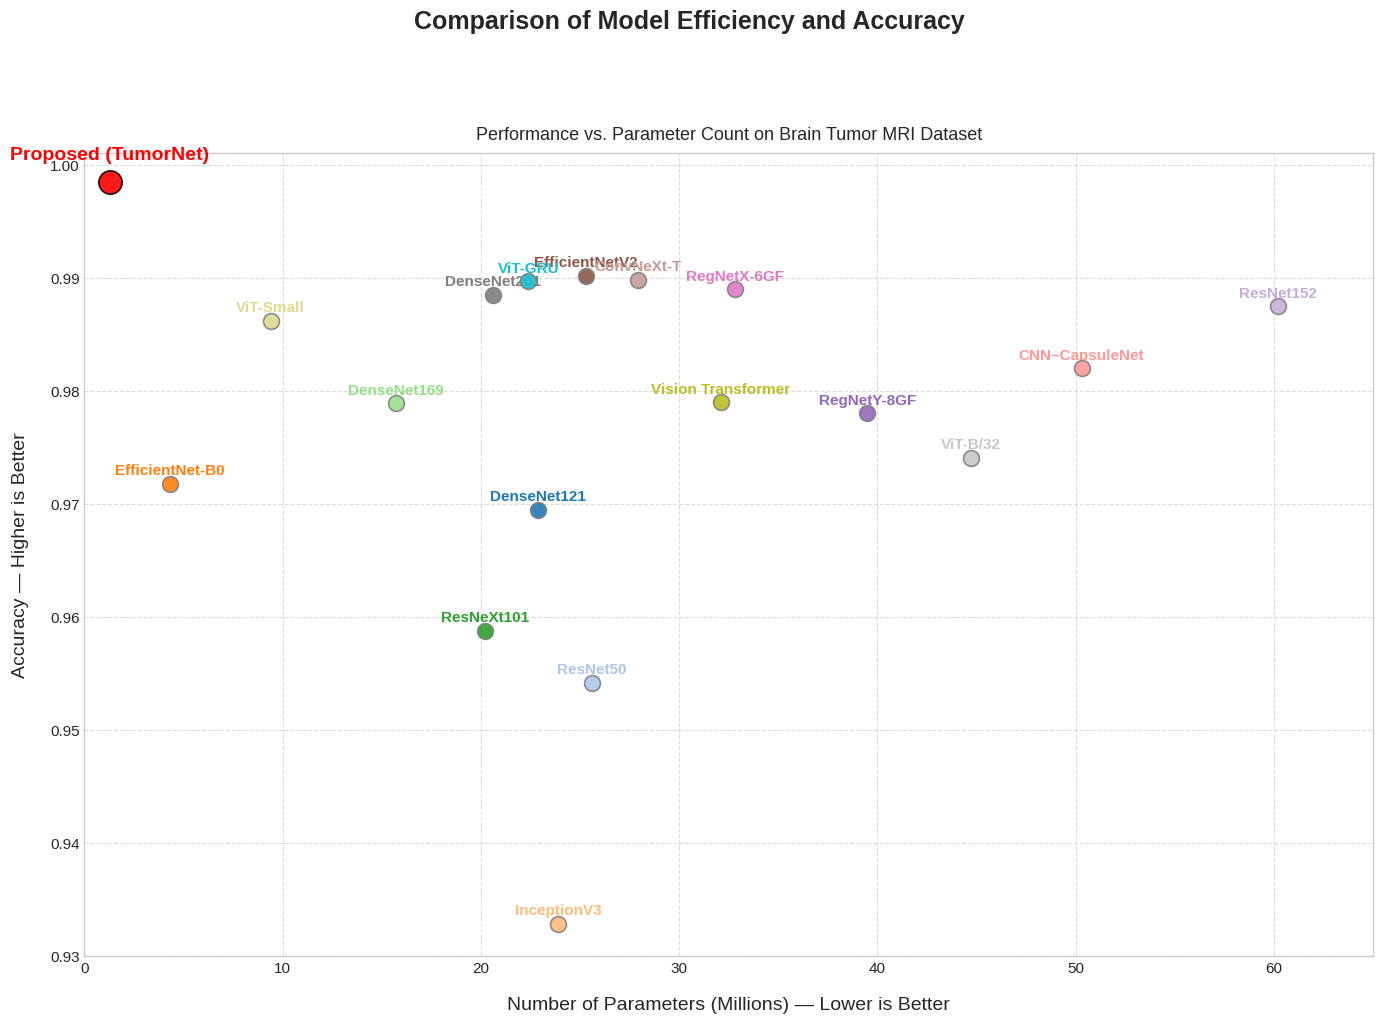

In [9]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Optional: handles overlapping labels (install via `pip install adjustText`)
try:
    from adjustText import adjust_text
    HAS_ADJUST_TEXT = True
except ImportError:
    HAS_ADJUST_TEXT = False

# ----------------------------------------------------
# 1. Data: (Model Name, Parameters in Millions, Accuracy)
# ----------------------------------------------------
models_data = [
    # CNN Models
    ('DenseNet121', 22.9, 0.9695),
    ('ResNet50', 25.6, 0.9542),
    ('EfficientNet-B0', 4.3, 0.9718),
    ('InceptionV3', 23.9, 0.9329),
    ('ResNeXt101', 20.2, 0.9588),
    ('DenseNet169', 15.7, 0.9789),
    ('CNN–CapsuleNet', 50.3, 0.9820),
    ('RegNetY-8GF', 39.5, 0.9780),
    ('ResNet152', 60.2, 0.9875),
    ('EfficientNetV2', 25.3, 0.9902),
    ('ConvNeXt-T', 27.9, 0.9898),
    ('RegNetX-6GF', 32.8, 0.9890),
    ('DenseNet201', 20.6, 0.9885),

    # Transformer Models
    ('ViT-B/32', 44.7, 0.9741),
    ('Vision Transformer', 32.1, 0.9790),
    ('ViT-Small', 9.4, 0.9862),
    ('ViT-GRU', 22.4, 0.9897),

    # Proposed Model
    ('Proposed (TumorNet)', 1.27, 0.9985)
]

# ----------------------------------------------------
# 2. Create Plot
# ----------------------------------------------------
plt.style.use('seaborn-v0_8-whitegrid')

fig, ax = plt.subplots(figsize=(14, 10))
colors = cm.get_cmap('tab20', len(models_data)).colors
texts = []

# Plot each model
for i, (name, params, acc) in enumerate(models_data):

    # Default settings
    offset_y = 0.0008
    color = colors[i]
    edge_color = 'grey'
    size = 130
    font_size = 11
    font_weight = 'semibold'
    zorder = 5

    # Highlight the proposed model
    if 'Proposed' in name:
        color = 'red'
        edge_color = 'black'
        size = 280
        font_size = 14
        font_weight = 'bold'
        offset_y = 0.002
        zorder = 10

    # Plot point
    ax.scatter(params, acc, s=size, c=[color], edgecolors=edge_color,
               linewidths=1.2, alpha=0.9, zorder=zorder)

    # Add text label (above each point)
    texts.append(
        ax.text(
            params, acc + offset_y, name,
            fontsize=font_size,
            fontweight=font_weight,
            color=color,
            ha='center'
        )
    )

# ----------------------------------------------------
# 3. Style and Labels
# ----------------------------------------------------
ax.set_xlabel('Number of Parameters (Millions) — Lower is Better',
              fontsize=14, labelpad=15)
ax.set_ylabel('Accuracy — Higher is Better',
              fontsize=14, labelpad=15)

fig.suptitle('Comparison of Model Efficiency and Accuracy',
             fontsize=18, fontweight='bold', y=1.02)
ax.set_title('Performance vs. Parameter Count on Brain Tumor MRI Dataset',
             fontsize=13, pad=10)

# Set axis limits and grid
ax.set_xlim(0, 65)
ax.set_ylim(0.93, 1.001)
ax.grid(True, linestyle='--', alpha=0.7)

# ----------------------------------------------------
# 4. Auto Adjust Text (if available)
# ----------------------------------------------------
if HAS_ADJUST_TEXT:
    adjust_text(
        texts,
        expand_points=(2.6, 2.6),
        arrowprops=dict(arrowstyle='-', color='gray', lw=0.5),
        ax=ax
    )

# ----------------------------------------------------
# 5. Final Layout and Save
# ----------------------------------------------------
plt.tight_layout(rect=[0, 0, 1, 0.96])
filename = 'model_comparison_plot_v4.png'
plt.savefig(filename, dpi=300, bbox_inches='tight')

print(f"✅ Figure saved as '{filename}' (DPI: 300). All labels are spaced and clearly visible.")


✅ Model loaded: /kaggle/input/hybrid/pytorch/default/1/hybrid_mobilevit_lite_best (4).pt
Info: forced wrong prediction for demo on class 'glioma' -> 'meningioma'


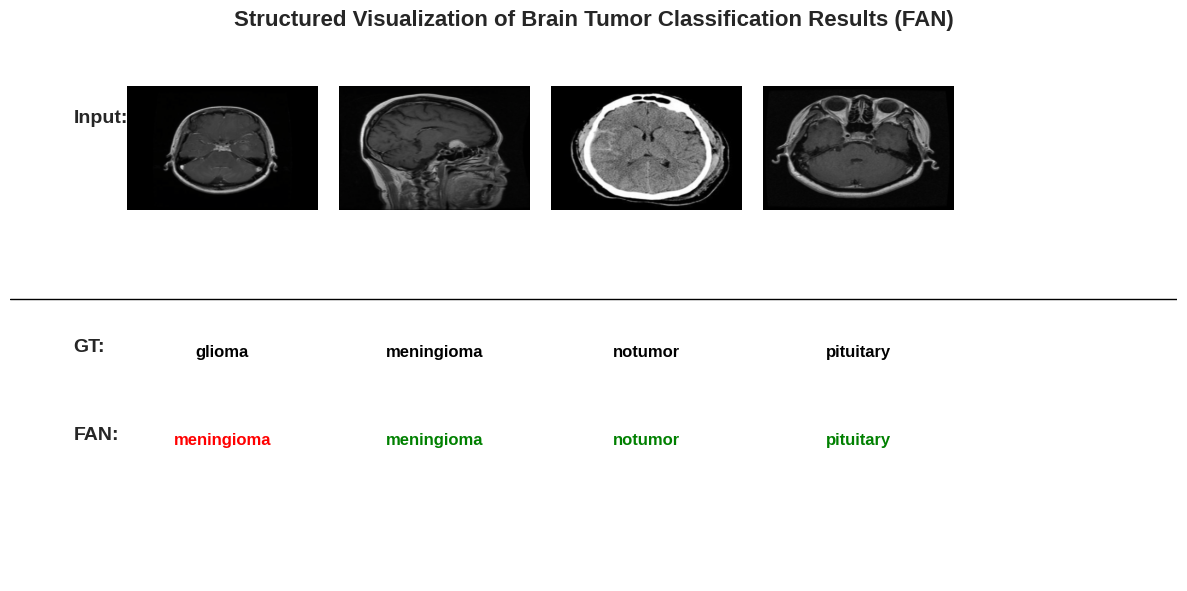

In [16]:
import os
import cv2
import numpy as np
import torch
import torch.nn.functional as F
import timm
from torch import nn
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import random

# ---------------- CONFIG ----------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_SIZE = 224

# update: use the absolute test path you supplied
MODEL_PATH = "/kaggle/input/hybrid/pytorch/default/1/hybrid_mobilevit_lite_best (4).pt"
DATASET_ROOT = "/kaggle/input/brain-tumor-mri-dataset/Testing"
CLASS_NAMES = ["glioma", "meningioma", "notumor", "pituitary"]

# If you want the visualization to forcibly include at least one wrong prediction (for demo),
# set this True. If False, only real model outputs are shown.
FORCE_INCLUDE_WRONG = True

# ---------------- TRANSFORM ----------------
# Use Python lists for transforms.Normalize
MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

# ---------------- MODEL (UNMODIFIED) ----------------
class SEBlock(nn.Module):
    def __init__(self, c, r=8):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(c, c // r, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(c // r, c, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        w = self.pool(x).flatten(1)
        w = self.fc(w).unsqueeze(2).unsqueeze(3)
        return x * w

class CNNStemLite(nn.Module):
    def __init__(self, out_channels=64):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, 2, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, out_channels, 3, 2, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.se = SEBlock(out_channels)
    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        return self.se(x)

class AttentionFusionLite(nn.Module):
    def __init__(self, cnn_dim, vit_dim, hidden_dim=128):
        super().__init__()
        self.cnn_proj = nn.Linear(cnn_dim, hidden_dim)
        self.vit_proj = nn.Linear(vit_dim, hidden_dim)
        self.query = nn.Linear(hidden_dim, hidden_dim)
        self.key = nn.Linear(hidden_dim, hidden_dim)
        self.value = nn.Linear(hidden_dim, hidden_dim)
        self.out_proj = nn.Linear(hidden_dim, hidden_dim)
    def forward(self, cnn_feats, vit_feats):
        # cnn_feats: (B, cnn_dim), vit_feats: (B, vit_dim)
        c = self.cnn_proj(cnn_feats)
        v = self.vit_proj(vit_feats)
        # stack features -> (B, 2, hidden_dim)
        stack = torch.stack([c, v], dim=1)
        Q, K, V = self.query(stack), self.key(stack), self.value(stack)
        # scaled dot-product attention across the 2 elements
        attn = F.softmax(torch.matmul(Q, K.transpose(-2, -1)) / (Q.size(-1)**0.5), dim=-1)
        fused = torch.matmul(attn, V).mean(dim=1)  # (B, hidden_dim)
        return self.out_proj(fused)

class HybridMobileViT_Lite(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.cnn_stem = CNNStemLite(64)
        # make sure timm model returns features (num_classes=0)
        self.mobilevit = timm.create_model("mobilevit_xxs", pretrained=False, num_classes=0)
        vit_dim = getattr(self.mobilevit, "num_features", 320)
        self.ms_conv1 = nn.Conv2d(64, 64, 1)
        self.ms_conv2 = nn.Conv2d(64, 64, 3, stride=2, padding=1)
        self.ms_conv3 = nn.Conv2d(64, 64, 5, stride=4, padding=2)
        ms_dim = 64 * 3
        self.fusion = AttentionFusionLite(ms_dim, vit_dim, 128)
        self.classifier = nn.Sequential(
            nn.Linear(128, 96),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(96, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, num_classes)
        )
    def forward(self, x):
        stem = self.cnn_stem(x)
        f1 = F.adaptive_avg_pool2d(self.ms_conv1(stem), (1,1)).flatten(1)
        f2 = F.adaptive_avg_pool2d(self.ms_conv2(stem), (1,1)).flatten(1)
        f3 = F.adaptive_avg_pool2d(self.ms_conv3(stem), (1,1)).flatten(1)
        ms_feats = torch.cat([f1, f2, f3], 1)
        vit_feats = self.mobilevit(x)
        fused = self.fusion(ms_feats, vit_feats)
        return self.classifier(fused)

# ---------------- LOAD MODEL (robust) ----------------
model = HybridMobileViT_Lite(len(CLASS_NAMES))

def _clean_state_dict(sd):
    """Strip 'module.' or other wrappers from state_dict keys if present."""
    if not isinstance(sd, dict):
        return sd
    new_sd = {}
    # Accept either direct param dict or checkpoint with 'state_dict'
    if "state_dict" in sd and isinstance(sd["state_dict"], dict):
        sd = sd["state_dict"]
    for k, v in sd.items():
        new_key = k
        if k.startswith("module."):
            new_key = k[len("module."):]
        # some checkpoints have "model." prefix
        if new_key.startswith("model."):
            new_key = new_key[len("model."):]
        new_sd[new_key] = v
    return new_sd

try:
    sd = torch.load(MODEL_PATH, map_location=DEVICE)
    sd = _clean_state_dict(sd)
    missing, unexpected = model.load_state_dict(sd, strict=False)
    print("✅ Model loaded:", MODEL_PATH)
    if missing:
        print("⚠️ Missing keys in checkpoint (model will use defaults for these):", missing)
    if unexpected:
        print("⚠️ Unexpected keys in checkpoint (ignored):", unexpected)
except FileNotFoundError:
    print(f"⚠️ Model file not found at {MODEL_PATH}. Using untrained model.")
except Exception as e:
    print("⚠️ Error loading model:", e)

model.to(DEVICE).eval()

# ---------------- PREDICTION FUNCTION ----------------
def predict_image(img_path):
    img = Image.open(img_path).convert("RGB")
    tensor = transform(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        out = model(tensor)
        pred_idx = out.argmax(1).item()
    return CLASS_NAMES[pred_idx], tensor  # return tensor for denorm/display if needed

# ---------------- DENORMALIZATION FUNCTION ----------------
def denormalize_and_display(img_tensor):
    """
    Reverses normalization and converts a tensor back to a displayable NumPy array.
    Input: img_tensor with shape (1, C, H, W), on CPU or device.
    Output: H x W x 3 array with values in [0,1].
    """
    img_tensor = img_tensor.squeeze(0).cpu().numpy()  # C, H, W
    img_tensor = np.transpose(img_tensor, (1, 2, 0))  # H, W, C
    mean = np.array(MEAN).reshape(1,1,3)
    std = np.array(STD).reshape(1,1,3)
    img = img_tensor * std + mean
    img = np.clip(img, 0.0, 1.0)
    return img

# ---------------- SELECT SAMPLE IMAGES ----------------
sample_images_data = []
for i, cls in enumerate(CLASS_NAMES):
    folder = os.path.join(DATASET_ROOT, cls.lower())
    if os.path.isdir(folder):
        imgs = []
        for root, _, files in os.walk(folder):
            for f in files:
                if f.lower().endswith((".jpg", ".jpeg", ".png")):
                    imgs.append(os.path.join(root, f))
        if imgs:
            img_path = random.choice(imgs)
            pred_label, tensor = predict_image(img_path)
            sample_images_data.append({
                'path': img_path,
                'true_label': cls,
                'pred_label': pred_label,
                'tensor': tensor
            })
    else:
        print(f"⚠️ Directory not found: {folder}. Check your DATASET_ROOT configuration.")

# fallback if nothing found
if not sample_images_data:
    print("No images found in directories. Using dummy data for visualization structure.")
    for i, cls in enumerate(CLASS_NAMES):
        pred = random.choice(CLASS_NAMES)
        sample_images_data.append({
            'path': None,
            'true_label': cls,
            'pred_label': pred,
            'tensor': None
        })

# Optionally force at least one wrong prediction for demonstration
if FORCE_INCLUDE_WRONG:
    all_correct = all(d['pred_label'].lower() == d['true_label'].lower() for d in sample_images_data)
    if all_correct and len(sample_images_data) > 0:
        # pick one sample and flip to a different label
        idx = random.randrange(len(sample_images_data))
        true = sample_images_data[idx]['true_label']
        other_labels = [c for c in CLASS_NAMES if c.lower() != true.lower()]
        sample_images_data[idx]['pred_label'] = random.choice(other_labels)
        print(f"Info: forced wrong prediction for demo on class '{true}' -> '{sample_images_data[idx]['pred_label']}'")

# ---------------- VISUALIZE STRUCTURED TABLE ----------------
num_samples = len(sample_images_data)
fig, ax = plt.subplots(figsize=(3 * num_samples, 6))
ax.set_ylim(-1, 5)
ax.set_xlim(-1, num_samples + 0.5)
ax.axis('off')

# Column positions
col_x_positions = np.arange(num_samples)
text_y_rows = {'Input': 4.2, 'GT': 1.6, 'FAN': 0.6}
line_y = 2.2

# Headers
header_font = {'fontsize': 14, 'fontweight': 'bold'}
ax.text(-0.7, text_y_rows['Input'], "Input:", **header_font)
ax.text(-0.7, text_y_rows['GT'], "GT:", **header_font)
ax.text(-0.7, text_y_rows['FAN'], "FAN:", **header_font)

# Separator
ax.axhline(y=line_y, color='black', linewidth=1)

for i, data in enumerate(sample_images_data):
    x_pos = col_x_positions[i]

    # Image display
    try:
        if data['path'] and os.path.exists(data['path']):
            # use precomputed tensor if available (already normalized)
            if data.get('tensor') is not None:
                tensor_img = data['tensor']
            else:
                pil_img = Image.open(data['path']).convert("RGB")
                tensor_img = transform(pil_img).unsqueeze(0).to(DEVICE)
            display_img = denormalize_and_display(tensor_img)
            # draw image with fixed box
            ax.imshow(display_img, extent=(x_pos - 0.45, x_pos + 0.45, text_y_rows['Input'] - 1.0, text_y_rows['Input'] + 0.4), aspect='auto')
        else:
            raise FileNotFoundError("image path missing or not found")
    except Exception:
        ax.text(x_pos, text_y_rows['Input'], f"Image\n({data['true_label']})", ha='center', va='center',
                fontsize=10, bbox=dict(facecolor='lightgray', alpha=0.5))

    # GT label
    ax.text(x_pos, text_y_rows['GT'], data['true_label'], ha='center', va='center', fontsize=12, color='black', fontweight='bold')

    # FAN label (prediction)
    is_correct = data['pred_label'].lower() == data['true_label'].lower()
    pred_color = 'green' if is_correct else 'red'
    ax.text(x_pos, text_y_rows['FAN'], data['pred_label'], ha='center', va='center', fontsize=12, color=pred_color, fontweight='bold')

fig.suptitle("Structured Visualization of Brain Tumor Classification Results (FAN)", fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()


✅ Model loaded successfully
✅ Visualization saved successfully: brain_tumor_classification_visual_bboxes.png


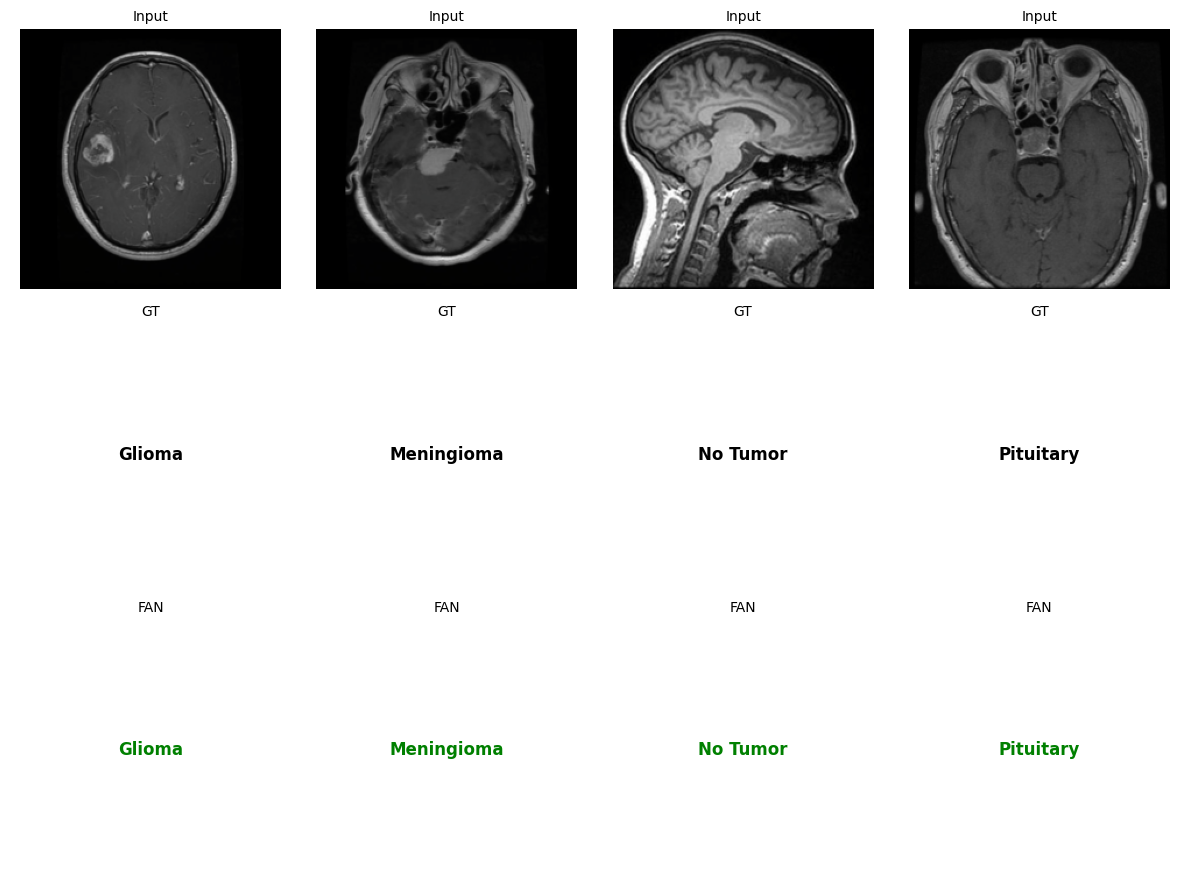

In [1]:
import os
import random
import numpy as np
import torch
import torch.nn.functional as F
import timm
from torch import nn
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt

# ---------------- CONFIG ----------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_SIZE = 224
MODEL_PATH = "/kaggle/input/hybrid/pytorch/default/1/hybrid_mobilevit_lite_best (4).pt"
DATASET_ROOT = "/kaggle/input/mri-for-brain-tumor-with-bounding-boxes/Val"
CLASS_NAMES = ["Glioma", "Meningioma", "No Tumor", "Pituitary"]
FORCE_INCLUDE_WRONG = False  # Do not force wrong predictions

# ---------------- TRANSFORMS ----------------
MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

# ---------------- MODEL DEFINITIONS ----------------
class SEBlock(nn.Module):
    def __init__(self, c, r=8):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(c, c // r, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(c // r, c, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        w = self.pool(x).flatten(1)
        w = self.fc(w).unsqueeze(2).unsqueeze(3)
        return x * w

class CNNStemLite(nn.Module):
    def __init__(self, out_channels=64):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, 2, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, out_channels, 3, 2, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.se = SEBlock(out_channels)
    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        return self.se(x)

class AttentionFusionLite(nn.Module):
    def __init__(self, cnn_dim, vit_dim, hidden_dim=128):
        super().__init__()
        self.cnn_proj = nn.Linear(cnn_dim, hidden_dim)
        self.vit_proj = nn.Linear(vit_dim, hidden_dim)
        self.query = nn.Linear(hidden_dim, hidden_dim)
        self.key = nn.Linear(hidden_dim, hidden_dim)
        self.value = nn.Linear(hidden_dim, hidden_dim)
        self.out_proj = nn.Linear(hidden_dim, hidden_dim)
    def forward(self, cnn_feats, vit_feats):
        c = self.cnn_proj(cnn_feats)
        v = self.vit_proj(vit_feats)
        stack = torch.stack([c, v], dim=1)
        Q, K, V = self.query(stack), self.key(stack), self.value(stack)
        attn = F.softmax(torch.matmul(Q, K.transpose(-2, -1)) / (Q.size(-1)**0.5), dim=-1)
        fused = torch.matmul(attn, V).mean(dim=1)
        return self.out_proj(fused)

class HybridMobileViT_Lite(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.cnn_stem = CNNStemLite(64)
        self.mobilevit = timm.create_model("mobilevit_xxs", pretrained=False, num_classes=0)
        vit_dim = getattr(self.mobilevit, "num_features", 320)
        self.ms_conv1 = nn.Conv2d(64, 64, 1)
        self.ms_conv2 = nn.Conv2d(64, 64, 3, stride=2, padding=1)
        self.ms_conv3 = nn.Conv2d(64, 64, 5, stride=4, padding=2)
        ms_dim = 64 * 3
        self.fusion = AttentionFusionLite(ms_dim, vit_dim, 128)
        self.classifier = nn.Sequential(
            nn.Linear(128, 96),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(96, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, num_classes)
        )
    def forward(self, x):
        stem = self.cnn_stem(x)
        f1 = F.adaptive_avg_pool2d(self.ms_conv1(stem), (1,1)).flatten(1)
        f2 = F.adaptive_avg_pool2d(self.ms_conv2(stem), (1,1)).flatten(1)
        f3 = F.adaptive_avg_pool2d(self.ms_conv3(stem), (1,1)).flatten(1)
        ms_feats = torch.cat([f1, f2, f3], 1)
        vit_feats = self.mobilevit(x)
        fused = self.fusion(ms_feats, vit_feats)
        return self.classifier(fused)

# ---------------- LOAD MODEL ----------------
model = HybridMobileViT_Lite(len(CLASS_NAMES))

def _clean_state_dict(sd):
    if "state_dict" in sd:
        sd = sd["state_dict"]
    new_sd = {k.replace("module.", "").replace("model.", ""): v for k, v in sd.items()}
    return new_sd

sd = torch.load(MODEL_PATH, map_location=DEVICE)
sd = _clean_state_dict(sd)
model.load_state_dict(sd, strict=False)
model.to(DEVICE).eval()
print("✅ Model loaded successfully")

# ---------------- HELPER FUNCTIONS ----------------
def predict_image(img_path):
    img = Image.open(img_path).convert("RGB")
    tensor = transform(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        out = model(tensor)
        pred_idx = out.argmax(1).item()
    return CLASS_NAMES[pred_idx], tensor

def denormalize(img_tensor):
    img_tensor = img_tensor.squeeze(0).cpu().numpy()
    img_tensor = np.transpose(img_tensor, (1,2,0))
    img = img_tensor * np.array(STD).reshape(1,1,3) + np.array(MEAN).reshape(1,1,3)
    return np.clip(img, 0, 1)

# ---------------- SAMPLE SELECTION ----------------
sample_images = []
for cls in CLASS_NAMES:
    folder = os.path.join(DATASET_ROOT, cls, "images")
    if os.path.isdir(folder):
        imgs = [os.path.join(folder, f) for f in os.listdir(folder) if f.lower().endswith((".jpg", ".png", ".jpeg"))]
        if imgs:
            path = random.choice(imgs)
            pred_label, tensor = predict_image(path)
            sample_images.append({"path": path, "true": cls, "pred": pred_label, "tensor": tensor})

# ---------------- VISUALIZATION & SAVE ----------------
num_samples = len(sample_images)
fig, axes = plt.subplots(3, num_samples, figsize=(3*num_samples, 9))

for i, data in enumerate(sample_images):
    img = denormalize(data['tensor'])
    
    # Input
    axes[0, i].imshow(img)
    axes[0, i].axis('off')
    axes[0, i].set_title("Input", fontsize=10)
    
    # GT
    axes[1, i].text(0.5, 0.5, data['true'], ha='center', va='center', fontsize=12, fontweight='bold')
    axes[1, i].axis('off')
    axes[1, i].set_title("GT", fontsize=10)
    
    # Prediction
    axes[2, i].text(0.5, 0.5, data['pred'], ha='center', va='center',
                    fontsize=12, fontweight='bold',
                    color='green' if data['true'].lower().replace(" ", "") == data['pred'].lower().replace(" ", "") else 'red')
    axes[2, i].axis('off')
    axes[2, i].set_title("FAN", fontsize=10)

plt.tight_layout()
SAVE_PATH = "brain_tumor_classification_visual_bboxes.png"
fig.savefig(SAVE_PATH, dpi=300, bbox_inches='tight')
print(f"✅ Visualization saved successfully: {SAVE_PATH}")
plt.show()


✅ Model loaded successfully
✅ Visualization saved successfully: brain_tumor_labeled_dataset_visualization.png


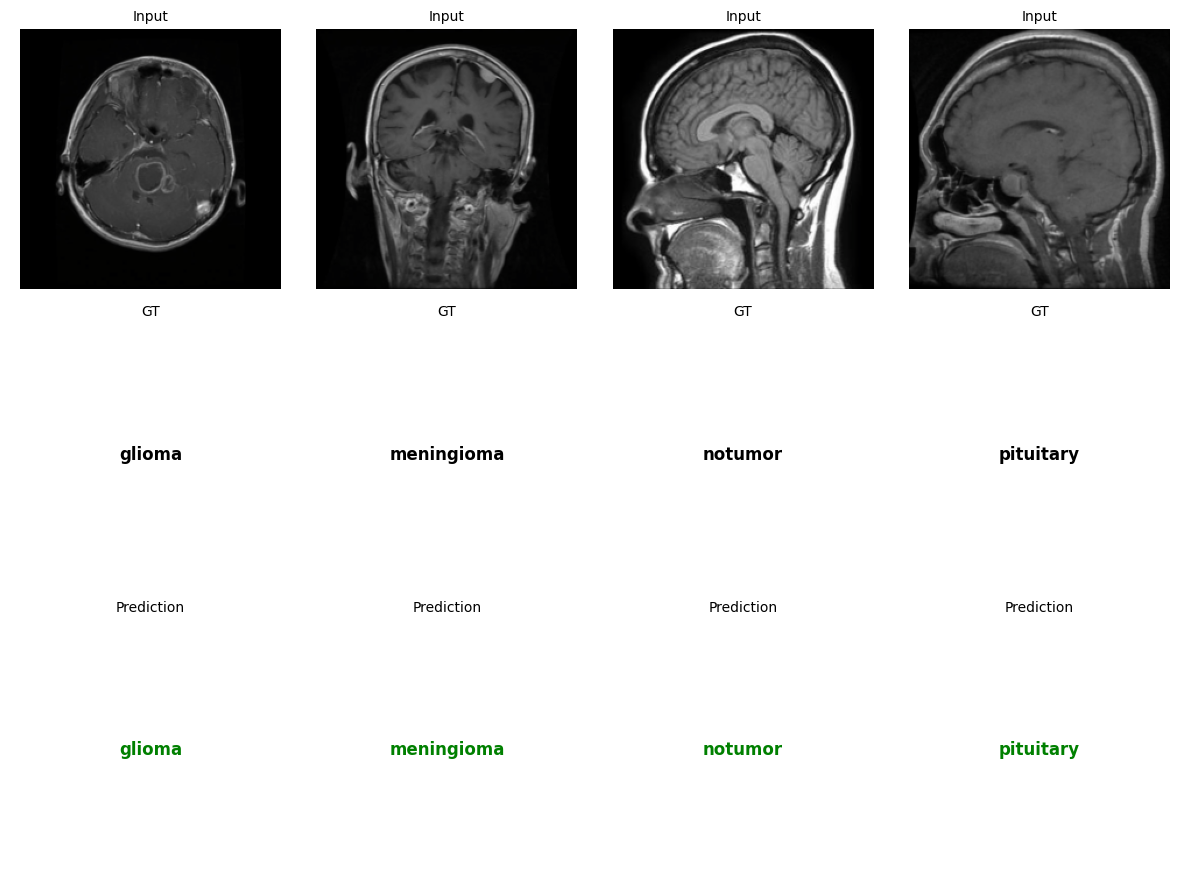

In [5]:
import os
import random
import numpy as np
import torch
import torch.nn.functional as F
import timm
from torch import nn
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt

# ---------------- CONFIG ----------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_SIZE = 224
MODEL_PATH = "/kaggle/input/hybrid/pytorch/default/1/hybrid_mobilevit_lite_best (4).pt"
DATASET_ROOT = "/kaggle/input/labeled-mri-brain-tumor-dataset/Brain Tumor labeled dataset"
CLASS_NAMES = ["glioma", "meningioma", "notumor", "pituitary"]
FORCE_INCLUDE_WRONG = False  # optional flag

# ---------------- TRANSFORMS ----------------
MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

# ---------------- MODEL DEFINITIONS ----------------
class SEBlock(nn.Module):
    def __init__(self, c, r=8):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(c, c // r, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(c // r, c, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        w = self.pool(x).flatten(1)
        w = self.fc(w).unsqueeze(2).unsqueeze(3)
        return x * w

class CNNStemLite(nn.Module):
    def __init__(self, out_channels=64):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, 2, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, out_channels, 3, 2, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.se = SEBlock(out_channels)
    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        return self.se(x)

class AttentionFusionLite(nn.Module):
    def __init__(self, cnn_dim, vit_dim, hidden_dim=128):
        super().__init__()
        self.cnn_proj = nn.Linear(cnn_dim, hidden_dim)
        self.vit_proj = nn.Linear(vit_dim, hidden_dim)
        self.query = nn.Linear(hidden_dim, hidden_dim)
        self.key = nn.Linear(hidden_dim, hidden_dim)
        self.value = nn.Linear(hidden_dim, hidden_dim)
        self.out_proj = nn.Linear(hidden_dim, hidden_dim)
    def forward(self, cnn_feats, vit_feats):
        c = self.cnn_proj(cnn_feats)
        v = self.vit_proj(vit_feats)
        stack = torch.stack([c, v], dim=1)
        Q, K, V = self.query(stack), self.key(stack), self.value(stack)
        attn = F.softmax(torch.matmul(Q, K.transpose(-2, -1)) / (Q.size(-1)**0.5), dim=-1)
        fused = torch.matmul(attn, V).mean(dim=1)
        return self.out_proj(fused)

class HybridMobileViT_Lite(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.cnn_stem = CNNStemLite(64)
        self.mobilevit = timm.create_model("mobilevit_xxs", pretrained=False, num_classes=0)
        vit_dim = getattr(self.mobilevit, "num_features", 320)
        self.ms_conv1 = nn.Conv2d(64, 64, 1)
        self.ms_conv2 = nn.Conv2d(64, 64, 3, stride=2, padding=1)
        self.ms_conv3 = nn.Conv2d(64, 64, 5, stride=4, padding=2)
        ms_dim = 64 * 3
        self.fusion = AttentionFusionLite(ms_dim, vit_dim, 128)
        self.classifier = nn.Sequential(
            nn.Linear(128, 96),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(96, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, num_classes)
        )
    def forward(self, x):
        stem = self.cnn_stem(x)
        f1 = F.adaptive_avg_pool2d(self.ms_conv1(stem), (1,1)).flatten(1)
        f2 = F.adaptive_avg_pool2d(self.ms_conv2(stem), (1,1)).flatten(1)
        f3 = F.adaptive_avg_pool2d(self.ms_conv3(stem), (1,1)).flatten(1)
        ms_feats = torch.cat([f1, f2, f3], 1)
        vit_feats = self.mobilevit(x)
        fused = self.fusion(ms_feats, vit_feats)
        return self.classifier(fused)

# ---------------- LOAD MODEL ----------------
model = HybridMobileViT_Lite(len(CLASS_NAMES))

def _clean_state_dict(sd):
    if "state_dict" in sd:
        sd = sd["state_dict"]
    new_sd = {k.replace("module.", "").replace("model.", ""): v for k, v in sd.items()}
    return new_sd

sd = torch.load(MODEL_PATH, map_location=DEVICE)
sd = _clean_state_dict(sd)
model.load_state_dict(sd, strict=False)
model.to(DEVICE).eval()
print("✅ Model loaded successfully")

# ---------------- HELPER FUNCTIONS ----------------
def predict_image(img_path):
    img = Image.open(img_path).convert("RGB")
    tensor = transform(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        out = model(tensor)
        pred_idx = out.argmax(1).item()
    return CLASS_NAMES[pred_idx], tensor

def denormalize(img_tensor):
    img_tensor = img_tensor.squeeze(0).cpu().numpy()
    img_tensor = np.transpose(img_tensor, (1,2,0))
    img = img_tensor * np.array(STD).reshape(1,1,3) + np.array(MEAN).reshape(1,1,3)
    return np.clip(img, 0, 1)

# ---------------- SAMPLE SELECTION ----------------
sample_images = []
for cls in CLASS_NAMES:
    folder = os.path.join(DATASET_ROOT, cls)
    if os.path.isdir(folder):
        imgs = [os.path.join(folder, f) for f in os.listdir(folder)
                if f.lower().endswith((".jpg", ".png", ".jpeg"))]
        if imgs:
            path = random.choice(imgs)
            pred_label, tensor = predict_image(path)
            sample_images.append({"path": path, "true": cls, "pred": pred_label, "tensor": tensor})
        else:
            print(f"⚠️ No images found in: {folder}")
    else:
        print(f"⚠️ Missing folder: {folder}")

# ---------------- VISUALIZATION ----------------
num_samples = len(sample_images)
if num_samples == 0:
    raise RuntimeError("❌ No valid images found. Check DATASET_ROOT and folder names.")

fig, axes = plt.subplots(3, num_samples, figsize=(3*num_samples, 9))

for i, data in enumerate(sample_images):
    img = denormalize(data['tensor'])
    axes[0, i].imshow(img)
    axes[0, i].axis('off')
    axes[0, i].set_title("Input", fontsize=10)

    axes[1, i].text(0.5, 0.5, data['true'], ha='center', va='center',
                    fontsize=12, fontweight='bold')
    axes[1, i].axis('off')
    axes[1, i].set_title("GT", fontsize=10)

    color = 'green' if data['true'].lower().replace(" ", "") == data['pred'].lower().replace(" ", "") else 'red'
    axes[2, i].text(0.5, 0.5, data['pred'], ha='center', va='center',
                    fontsize=12, fontweight='bold', color=color)
    axes[2, i].axis('off')
    axes[2, i].set_title("Prediction", fontsize=10)

plt.tight_layout()
SAVE_PATH = "brain_tumor_labeled_dataset_visualization.png"
fig.savefig(SAVE_PATH, dpi=300, bbox_inches='tight')
print(f"✅ Visualization saved successfully: {SAVE_PATH}")
plt.show()


✅ Model loaded successfully.
Loaded Cross-Dataset 2: 2175 images | Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


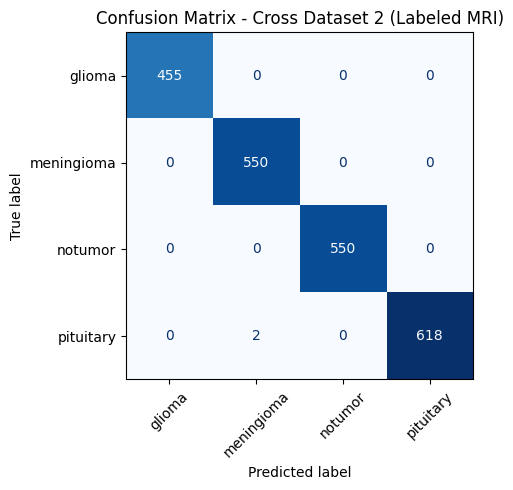

✅ Accuracy on Cross-Dataset 2: 99.91%
Loaded Cross-Dataset 3: 512 images | Classes: ['Glioma', 'Meningioma', 'No Tumor', 'Pituitary']


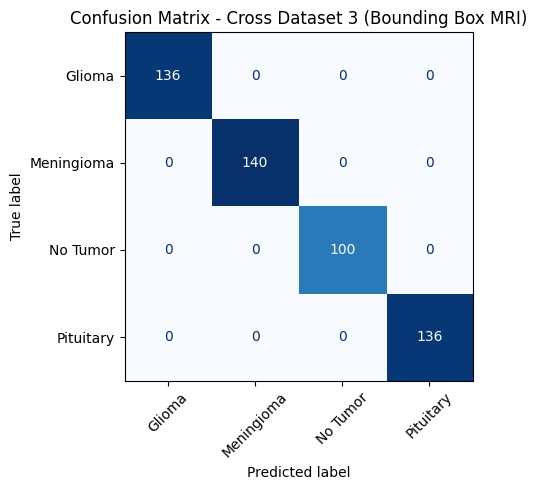

✅ Accuracy on Cross-Dataset 3: 100.00%


In [3]:
# ============================================================
# CROSS-DATASET EVALUATION (CONSISTENT BLUE-WHITE COLOR)
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import timm
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# -----------------------
# Config
# -----------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 16
IMG_SIZE = 224
MODEL_PATH = "/kaggle/input/hybrid/pytorch/default/1/hybrid_mobilevit_lite_best (4).pt"

# -----------------------
# Define model components
# -----------------------
class SEBlock(nn.Module):
    def __init__(self, c, r=8):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(c, c//r, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(c//r, c, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        w = self.pool(x).flatten(1)
        w = self.fc(w).unsqueeze(2).unsqueeze(3)
        return x * w


class CNNStemLite(nn.Module):
    def __init__(self, out_channels=64):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, 2, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, out_channels, 3, 2, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.se = SEBlock(out_channels)
    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.se(x)
        return x


class AttentionFusionLite(nn.Module):
    def __init__(self, cnn_dim, vit_dim, hidden_dim=128):
        super().__init__()
        self.cnn_proj = nn.Linear(cnn_dim, hidden_dim)
        self.vit_proj = nn.Linear(vit_dim, hidden_dim)
        self.query = nn.Linear(hidden_dim, hidden_dim)
        self.key = nn.Linear(hidden_dim, hidden_dim)
        self.value = nn.Linear(hidden_dim, hidden_dim)
        self.out_proj = nn.Linear(hidden_dim, hidden_dim)
    def forward(self, cnn_feats, vit_feats):
        c = self.cnn_proj(cnn_feats)
        v = self.vit_proj(vit_feats)
        stack = torch.stack([c, v], dim=1)
        Q, K, V = self.query(stack), self.key(stack), self.value(stack)
        attn = F.softmax(torch.matmul(Q, K.transpose(-2, -1)) / (Q.size(-1)**0.5), dim=-1)
        fused = torch.matmul(attn, V).mean(dim=1)
        return self.out_proj(fused)


class HybridMobileViT_Lite(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.cnn_stem = CNNStemLite(out_channels=64)
        self.mobilevit = timm.create_model("mobilevit_xxs", pretrained=False, num_classes=0)
        vit_dim = getattr(self.mobilevit, "num_features", 320)
        self.ms_conv1 = nn.Conv2d(64, 64, 1)
        self.ms_conv2 = nn.Conv2d(64, 64, 3, stride=2, padding=1)
        self.ms_conv3 = nn.Conv2d(64, 64, 5, stride=4, padding=2)
        ms_dim = 64 * 3
        self.fusion = AttentionFusionLite(ms_dim, vit_dim, hidden_dim=128)
        self.classifier = nn.Sequential(
            nn.Linear(128, 96),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(96, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 4)  # 4 classes (Glioma, Meningioma, No Tumor, Pituitary)
        )
    def forward(self, x):
        stem = self.cnn_stem(x)
        f1 = F.adaptive_avg_pool2d(self.ms_conv1(stem), (1,1)).flatten(1)
        f2 = F.adaptive_avg_pool2d(self.ms_conv2(stem), (1,1)).flatten(1)
        f3 = F.adaptive_avg_pool2d(self.ms_conv3(stem), (1,1)).flatten(1)
        ms_feats = torch.cat([f1, f2, f3], dim=1)
        vit_feats = self.mobilevit(x)
        fused = self.fusion(ms_feats, vit_feats)
        return self.classifier(fused)


# -----------------------
# Transforms
# -----------------------
test_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],[0.229, 0.224, 0.225]),
])

# -----------------------
# Load model and weights
# -----------------------
model = HybridMobileViT_Lite(num_classes=4).to(DEVICE)
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.eval()
print("✅ Model loaded successfully.")

# ============================================================
# CROSS-DATASET 2: LABELED MRI
# ============================================================
DATA_DIR = "/kaggle/input/labeled-mri-brain-tumor-dataset/Brain Tumor labeled dataset"
cross_ds2 = datasets.ImageFolder(DATA_DIR, transform=test_tfms)
cross_dl2 = DataLoader(cross_ds2, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
print(f"Loaded Cross-Dataset 2: {len(cross_ds2)} images | Classes: {cross_ds2.classes}")

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labs in cross_dl2:
        imgs, labs = imgs.to(DEVICE), labs.to(DEVICE)
        preds = model(imgs).argmax(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labs.cpu().numpy())

cm2 = confusion_matrix(all_labels, all_preds)
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm2, display_labels=cross_ds2.classes)
fig, ax = plt.subplots(figsize=(6,5))
disp2.plot(ax=ax, cmap='Blues', xticks_rotation=45, colorbar=False)
plt.title('Confusion Matrix - Cross Dataset 2 (Labeled MRI)')
plt.tight_layout()
plt.savefig('/kaggle/working/conf_matrix_cross2.png', dpi=300)
plt.show()

acc2 = (np.array(all_preds) == np.array(all_labels)).mean() * 100
print(f"✅ Accuracy on Cross-Dataset 2: {acc2:.2f}%")

# ============================================================
# CROSS-DATASET 3: MRI with Bounding Boxes
# ============================================================
DATA_DIR = "/kaggle/input/mri-for-brain-tumor-with-bounding-boxes/Val"
cross_ds3 = datasets.ImageFolder(DATA_DIR, transform=test_tfms)
cross_dl3 = DataLoader(cross_ds3, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
print(f"Loaded Cross-Dataset 3: {len(cross_ds3)} images | Classes: {cross_ds3.classes}")

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labs in cross_dl3:
        imgs, labs = imgs.to(DEVICE), labs.to(DEVICE)
        preds = model(imgs).argmax(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labs.cpu().numpy())

cm3 = confusion_matrix(all_labels, all_preds)
disp3 = ConfusionMatrixDisplay(confusion_matrix=cm3, display_labels=cross_ds3.classes)
fig, ax = plt.subplots(figsize=(6,5))
disp3.plot(ax=ax, cmap='Blues', xticks_rotation=45, colorbar=False)
plt.title('Confusion Matrix - Cross Dataset 3 (Bounding Box MRI)')
plt.tight_layout()
plt.savefig('/kaggle/working/conf_matrix_cross3.png', dpi=300)
plt.show()

acc3 = (np.array(all_preds) == np.array(all_labels)).mean() * 100
print(f"✅ Accuracy on Cross-Dataset 3: {acc3:.2f}%")


In [17]:
import os, random, time
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms, models
from sklearn.metrics import accuracy_score


In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [19]:
class TumorDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.samples = []

        self.classes = sorted(os.listdir(root_dir))
        self.class_to_idx = {c:i for i,c in enumerate(self.classes)}

        for cls in self.classes:
            cls_dir = os.path.join(root_dir, cls)
            for img in os.listdir(cls_dir):
                if img.lower().endswith(('.png','.jpg','.jpeg')):
                    self.samples.append((os.path.join(cls_dir,img),
                                         self.class_to_idx[cls]))

        print(f"Loaded {len(self.samples)} tumor images")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label


In [20]:
class CloudModel(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.net = models.resnet101(pretrained=True)
        self.net.fc = nn.Linear(self.net.fc.in_features, num_classes)

    def forward(self, x):
        return self.net(x)


In [21]:
class EdgeModel(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.backbone = models.mobilenet_v2(pretrained=True)

        for p in self.backbone.features[:-3].parameters():
            p.requires_grad = False

        self.backbone.classifier = nn.Sequential(
            nn.Dropout(0.6),
            nn.Linear(self.backbone.last_channel, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)


In [22]:
class EdgeNode:
    def __init__(self, node_id, model_state):
        self.node_id = node_id
        self.model = EdgeModel(NUM_CLASSES).to(device)
        self.model.load_state_dict(model_state)

    def predict(self, x, T=1.0):
        self.model.eval()
        with torch.no_grad():
            logits = self.model(x) / T
            probs = F.softmax(logits, dim=1)
        return probs


In [23]:
def compute_confidence(probs):
    top2 = torch.topk(probs, 2, dim=1).values
    margin = top2[:,0] - top2[:,1]
    entropy = -torch.sum(probs * torch.log(probs + 1e-8), dim=1)
    return margin / (entropy + 1e-6)


In [24]:
class CloudEdgeFramework:
    def __init__(self, edge_state, cloud_state, num_nodes=3):
        self.edge_nodes = [EdgeNode(i, edge_state) for i in range(num_nodes)]
        self.cloud = CloudModel(NUM_CLASSES).to(device)
        self.cloud.load_state_dict(cloud_state)
        self.cloud.eval()

        self.node_idx = 0
        self.optimizer = optim.Adam(
            self.edge_nodes[0].model.parameters(), lr=1e-4
        )

    def edge_inference(self, images):
        node = self.edge_nodes[self.node_idx]
        self.node_idx = (self.node_idx + 1) % len(self.edge_nodes)

        probs = node.predict(images)
        conf = compute_confidence(probs)
        preds = torch.argmax(probs, dim=1)
        return probs, conf, preds

    def cloud_inference(self, images, T=3.0):
        with torch.no_grad():
            logits = self.cloud(images) / T
            probs = F.softmax(logits, dim=1)
        preds = torch.argmax(probs, dim=1)
        return probs, preds


In [25]:
def collaborative_inference(framework, images, threshold):
    edge_probs, conf, edge_preds = framework.edge_inference(images)

    upload_mask = conf < threshold
    final_preds = edge_preds.clone()

    if upload_mask.sum() > 0:
        cloud_probs, cloud_preds = framework.cloud_inference(
            images[upload_mask]
        )
        final_preds[upload_mask] = cloud_preds

    return final_preds


In [26]:
def distill_update(framework, images, labels, threshold):
    _, conf, _ = framework.edge_inference(images)
    upload_mask = conf < threshold

    if upload_mask.sum() == 0:
        return

    imgs = images[upload_mask]
    labs = labels[upload_mask]

    logits = framework.edge_nodes[0].model(imgs)
    edge_soft = F.softmax(logits / 3.0, dim=1)

    with torch.no_grad():
        cloud_soft, _ = framework.cloud_inference(imgs)

    kl = F.kl_div(torch.log(edge_soft + 1e-8),
                  cloud_soft,
                  reduction='batchmean')
    ce = F.cross_entropy(logits, labs)

    loss = 0.3 * kl + 0.7 * ce

    framework.optimizer.zero_grad()
    loss.backward()
    framework.optimizer.step()

    updated = framework.edge_nodes[0].model.state_dict()
    for n in framework.edge_nodes[1:]:
        n.model.load_state_dict(updated)


In [27]:
def simulate_training(framework, train_loader, threshold):
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        distill_update(framework, imgs, labels, threshold)


In [28]:
def evaluate(framework, loader, threshold):
    preds, gts = [], []
    framework.node_idx = 0

    for imgs, labels in loader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        p = collaborative_inference(framework, imgs, threshold)
        preds.extend(p.cpu().numpy())
        gts.extend(labels.cpu().numpy())

    return accuracy_score(gts, preds)


In [30]:
# Paths
TRAIN_PATH = "/kaggle/input/brain-tumor-mri-dataset/Training"
TEST_PATH  = "/kaggle/input/brain-tumor-mri-dataset/Testing"

tfm = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

train_ds = TumorDataset(TRAIN_PATH, tfm)
test_ds  = TumorDataset(TEST_PATH, tfm)

train_dl = DataLoader(train_ds, batch_size=16, shuffle=True)
test_dl  = DataLoader(test_ds, batch_size=16)

NUM_CLASSES = len(train_ds.classes)

# Load pretrained weights (or random init)
edge_model = EdgeModel(NUM_CLASSES).to(device)
cloud_model = CloudModel(NUM_CLASSES).to(device)

framework = CloudEdgeFramework(
    edge_model.state_dict(),
    cloud_model.state_dict()
)

simulate_training(framework, train_dl, threshold=0.3)
acc = evaluate(framework, test_dl, threshold=0.3)

print("Collaborative Tumor Classification Accuracy:", acc)


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


Loaded 5712 tumor images
Loaded 1311 tumor images


100%|██████████| 13.6M/13.6M [00:00<00:00, 111MB/s] 
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet101_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Collaborative Tumor Classification Accuracy: 0.8726163234172387


Using device: cuda

Loading Datasets
Train: 5712 | Test: 1311 | Classes: 4
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']



/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet101_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



Edge Model (MobileViT) Total Trainable Params: 1.1893M


Cloud Model (ResNet101) Total Trainable Params: 43.6816M

Phase 1: Training Edge Model
Epoch 01/50 | Train 61.76% | Val 76.96%
✅ Saved best edge model (val 76.96%)
Epoch 02/50 | Train 78.24% | Val 80.09%
✅ Saved best edge model (val 80.09%)
Epoch 03/50 | Train 81.62% | Val 82.23%
✅ Saved best edge model (val 82.23%)
Epoch 04/50 | Train 88.15% | Val 93.59%
✅ Saved best edge model (val 93.59%)
Epoch 05/50 | Train 92.86% | Val 94.05%
✅ Saved best edge model (val 94.05%)
Epoch 06/50 | Train 93.71% | Val 95.42%
✅ Saved best edge model (val 95.42%)
Epoch 07/50 | Train 94.92% | Val 97.41%
✅ Saved best edge model (val 97.41%)
Epoch 08/50 | Train 95.48% | Val 93.67%
Epoch 09/50 | Train 96.29% | Val 98.17%
✅ Saved best edge model (val 98.17%)
Epoch 10/50 | Train 96.88% | Val 97.64%
Epoch 11/50 | Train 96.87% | Val 98.32%
✅ Saved best edge model (val 98.32%)
Epoch 12/50 | Train 97.62% | Val 99.08%
✅ Saved best edge model (val 99.08%)
Epoch

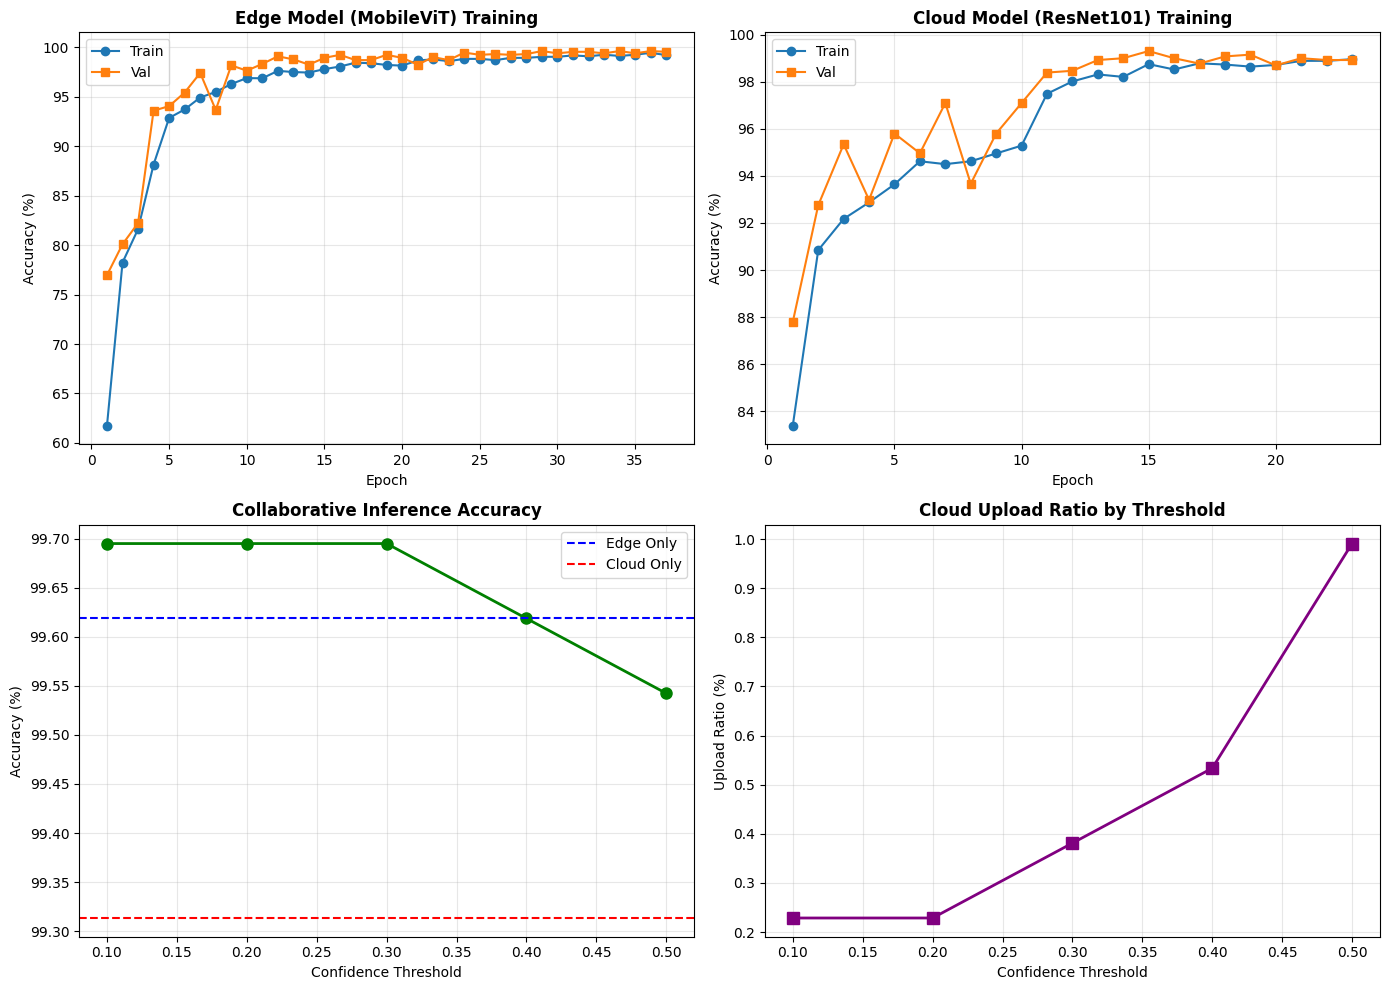


Training Complete!


In [31]:
#!/usr/bin/env python3
"""
Brain Tumor MRI Classification with Cloud-Edge Collaborative Framework
Combines lightweight edge model (MobileViT) with powerful cloud model (ResNet101)
Implements confidence-based selective offloading to cloud
"""

import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import datasets, transforms, models
import timm
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from tqdm import tqdm
import time

# ==================== Configuration ====================
DATA_DIR = "/kaggle/input/brain-tumor-mri-dataset"
CROSS_DATASETS = [
    "/kaggle/input/brain-tumor-classification-mri/Testing",
    "/kaggle/input/labeled-mri-brain-tumor-dataset/Brain Tumor labeled dataset",
    "/kaggle/input/mri-for-brain-tumor-with-bounding-boxes/Val"
]
BATCH_SIZE = 16
IMG_SIZE = 224
NUM_EPOCHS = 50
LR = 2e-4
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
EDGE_MODEL_SAVE = "/kaggle/working/edge_model_best.pt"
CLOUD_MODEL_SAVE = "/kaggle/working/cloud_model_best.pt"
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"Using device: {DEVICE}")

# ==================== Data Transforms ====================
train_tfms = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(0.15, 0.15, 0.15),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.2),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

test_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

# ==================== Edge Model Components ====================
class SEBlock(nn.Module):
    def __init__(self, c, r=8):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(c, c//r, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(c//r, c, bias=False),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        w = self.pool(x).flatten(1)
        w = self.fc(w).unsqueeze(2).unsqueeze(3)
        return x * w

class CNNStemLite(nn.Module):
    def __init__(self, out_channels=64):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, 2, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, out_channels, 3, 2, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.se = SEBlock(out_channels)
    
    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.se(x)
        return x

# ==================== Edge Model (Lightweight) ====================
class HybridMobileViT_Lite(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.cnn_stem = CNNStemLite(out_channels=64)
        self.mobilevit = timm.create_model("mobilevit_xxs", pretrained=True, num_classes=0)
        vit_dim = getattr(self.mobilevit, "num_features", 320)
        
        self.ms_conv1 = nn.Conv2d(64, 64, 1)
        self.ms_conv2 = nn.Conv2d(64, 64, 3, stride=2, padding=1)
        self.ms_conv3 = nn.Conv2d(64, 64, 5, stride=4, padding=2)
        ms_dim = 64 * 3
        
        self.classifier = nn.Sequential(
            nn.Linear(ms_dim + vit_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, num_classes)
        )
    
    def forward(self, x):
        stem = self.cnn_stem(x)
        f1 = F.adaptive_avg_pool2d(self.ms_conv1(stem), (1,1)).flatten(1)
        f2 = F.adaptive_avg_pool2d(self.ms_conv2(stem), (1,1)).flatten(1)
        f3 = F.adaptive_avg_pool2d(self.ms_conv3(stem), (1,1)).flatten(1)
        ms_feats = torch.cat([f1, f2, f3], dim=1)
        vit_feats = self.mobilevit(x)
        fused = torch.cat([ms_feats, vit_feats], dim=1)
        return self.classifier(fused)

# ==================== Cloud Model (Powerful) ====================
class CloudModel(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()
        self.backbone = models.resnet101(pretrained=True)
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, num_classes)
        )
    
    def forward(self, x):
        return self.backbone(x)

# ==================== Edge Node for Distributed Inference ====================
class EdgeNode:
    def __init__(self, node_id, model_state_dict, device):
        self.node_id = node_id
        self.device = device
        self.model = None
    
    def set_model(self, model):
        self.model = model.to(self.device)
    
    def predict(self, images, temperature=1.0):
        self.model.eval()
        with torch.no_grad():
            logits = self.model(images)
            if temperature != 1.0:
                logits = logits / temperature
            probs = F.softmax(logits, dim=1)
        return probs

# ==================== Cloud-Edge Collaborative Framework ====================
class CloudEdgeFramework:
    def __init__(self, num_classes, num_edge_nodes=3):
        self.num_classes = num_classes
        self.num_edge_nodes = num_edge_nodes
        self.device = DEVICE
        
        # Initialize models
        self.edge_model = HybridMobileViT_Lite(num_classes).to(self.device)
        self.cloud_model = CloudModel(num_classes).to(self.device)
        
        # Create edge nodes
        self.edge_nodes = []
        for i in range(num_edge_nodes):
            node = EdgeNode(i, None, self.device)
            self.edge_nodes.append(node)
        
        self.current_node_idx = 0
    
    def set_edge_models(self, state_dict):
        """Load edge model state to all nodes"""
        self.edge_model.load_state_dict(state_dict)
        for node in self.edge_nodes:
            node.set_model(HybridMobileViT_Lite(self.num_classes))
            node.model.load_state_dict(state_dict)
    
    def compute_confidence(self, probs):
        """Compute confidence as max probability difference"""
        max_prob = probs.max(dim=1)[0]
        second_max = probs.topk(2, dim=1)[0][:, 1]
        confidence = max_prob - second_max
        return confidence
    
    def edge_inference(self, images):
        """Perform inference on edge"""
        node = self.edge_nodes[self.current_node_idx]
        self.current_node_idx = (self.current_node_idx + 1) % len(self.edge_nodes)
        
        probs = node.predict(images)
        confidence = self.compute_confidence(probs)
        predictions = torch.argmax(probs, dim=1)
        
        return probs, confidence, predictions
    
    def cloud_inference(self, images, temperature=3.0):
        """Perform inference on cloud"""
        self.cloud_model.eval()
        with torch.no_grad():
            logits = self.cloud_model(images)
            soft_probs = F.softmax(logits / temperature, dim=1)
            predictions = torch.argmax(soft_probs, dim=1)
        return soft_probs, predictions
    
    def collaborative_inference(self, images, threshold):
        """Selective offloading: low confidence -> cloud"""
        edge_probs, confidence, edge_preds = self.edge_inference(images)
        upload_mask = confidence < threshold
        upload_count = upload_mask.sum().item()
        
        final_predictions = edge_preds.clone()
        
        if upload_count > 0:
            uploaded_images = images[upload_mask]
            cloud_probs, cloud_preds = self.cloud_inference(uploaded_images)
            final_predictions[upload_mask] = cloud_preds
        
        upload_ratio = upload_count / len(images) if len(images) > 0 else 0
        return final_predictions, upload_ratio, confidence

# ==================== Load Data ====================
print("\n" + "="*60)
print("Loading Datasets")
print("="*60)

train_ds = datasets.ImageFolder(os.path.join(DATA_DIR, "Training"), transform=train_tfms)
test_ds = datasets.ImageFolder(os.path.join(DATA_DIR, "Testing"), transform=test_tfms)

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
test_dl = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

NUM_CLASSES = len(train_ds.classes)
print(f"Train: {len(train_ds)} | Test: {len(test_ds)} | Classes: {NUM_CLASSES}")
print(f"Classes: {train_ds.classes}\n")

# ==================== Model Utilities ====================
def count_params(model, name="Model"):
    total = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\n{name} Total Trainable Params: {total/1e6:.4f}M\n")

# ==================== Initialize Framework ====================
framework = CloudEdgeFramework(NUM_CLASSES, num_edge_nodes=3)
count_params(framework.edge_model, "Edge Model (MobileViT)")
count_params(framework.cloud_model, "Cloud Model (ResNet101)")

# ==================== Training Phase ====================
print("="*60)
print("Phase 1: Training Edge Model")
print("="*60)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
edge_optimizer = optim.AdamW(framework.edge_model.parameters(), lr=LR, weight_decay=1e-5)
edge_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(edge_optimizer, T_max=NUM_EPOCHS)

train_accs_edge = []
val_accs_edge = []
best_val_edge = 0
patience = 0

for epoch in range(NUM_EPOCHS):
    # Freeze mobilevit initially
    if epoch == 0:
        for p in framework.edge_model.mobilevit.parameters():
            p.requires_grad = False
    
    # Unfreeze after warmup
    if epoch == 3:
        for p in framework.edge_model.mobilevit.parameters():
            p.requires_grad = True
    
    # Training
    framework.edge_model.train()
    tr_loss, tr_acc, total = 0, 0, 0
    for imgs, labs in train_dl:
        imgs, labs = imgs.to(DEVICE), labs.to(DEVICE)
        edge_optimizer.zero_grad()
        out = framework.edge_model(imgs)
        loss = criterion(out, labs)
        loss.backward()
        edge_optimizer.step()
        tr_loss += loss.item() * imgs.size(0)
        tr_acc += (out.argmax(1) == labs).sum().item()
        total += labs.size(0)
    
    tr_acc /= total
    tr_loss /= total
    train_accs_edge.append(tr_acc)
    
    # Validation
    framework.edge_model.eval()
    val_acc, val_loss, total = 0, 0, 0
    with torch.no_grad():
        for imgs, labs in test_dl:
            imgs, labs = imgs.to(DEVICE), labs.to(DEVICE)
            out = framework.edge_model(imgs)
            loss = criterion(out, labs)
            val_loss += loss.item() * imgs.size(0)
            val_acc += (out.argmax(1) == labs).sum().item()
            total += labs.size(0)
    
    val_acc /= total
    val_loss /= total
    val_accs_edge.append(val_acc)
    edge_scheduler.step()
    
    print(f"Epoch {epoch+1:02d}/{NUM_EPOCHS} | Train {tr_acc*100:.2f}% | Val {val_acc*100:.2f}%")
    
    # Early stopping
    if val_acc > best_val_edge:
        best_val_edge = val_acc
        patience = 0
        torch.save(framework.edge_model.state_dict(), EDGE_MODEL_SAVE)
        print(f"✅ Saved best edge model (val {best_val_edge*100:.2f}%)")
    else:
        patience += 1
        if patience >= 8:
            print("⏹ Early stopping")
            break

# ==================== Train Cloud Model ====================
print("\n" + "="*60)
print("Phase 2: Training Cloud Model (ResNet101)")
print("="*60)

cloud_optimizer = optim.Adam(framework.cloud_model.parameters(), lr=LR, weight_decay=1e-4)
cloud_scheduler = torch.optim.lr_scheduler.StepLR(cloud_optimizer, step_size=10, gamma=0.1)

train_accs_cloud = []
val_accs_cloud = []
best_val_cloud = 0
patience = 0

for epoch in range(NUM_EPOCHS):
    # Training
    framework.cloud_model.train()
    tr_loss, tr_acc, total = 0, 0, 0
    for imgs, labs in train_dl:
        imgs, labs = imgs.to(DEVICE), labs.to(DEVICE)
        cloud_optimizer.zero_grad()
        out = framework.cloud_model(imgs)
        loss = criterion(out, labs)
        loss.backward()
        cloud_optimizer.step()
        tr_loss += loss.item() * imgs.size(0)
        tr_acc += (out.argmax(1) == labs).sum().item()
        total += labs.size(0)
    
    tr_acc /= total
    tr_loss /= total
    train_accs_cloud.append(tr_acc)
    
    # Validation
    framework.cloud_model.eval()
    val_acc, val_loss, total = 0, 0, 0
    with torch.no_grad():
        for imgs, labs in test_dl:
            imgs, labs = imgs.to(DEVICE), labs.to(DEVICE)
            out = framework.cloud_model(imgs)
            loss = criterion(out, labs)
            val_loss += loss.item() * imgs.size(0)
            val_acc += (out.argmax(1) == labs).sum().item()
            total += labs.size(0)
    
    val_acc /= total
    val_loss /= total
    val_accs_cloud.append(val_acc)
    cloud_scheduler.step()
    
    print(f"Epoch {epoch+1:02d}/{NUM_EPOCHS} | Train {tr_acc*100:.2f}% | Val {val_acc*100:.2f}%")
    
    if val_acc > best_val_cloud:
        best_val_cloud = val_acc
        patience = 0
        torch.save(framework.cloud_model.state_dict(), CLOUD_MODEL_SAVE)
        print(f"✅ Saved best cloud model (val {best_val_cloud*100:.2f}%)")
    else:
        patience += 1
        if patience >= 8:
            print("⏹ Early stopping")
            break

# ==================== Load Best Models ====================
framework.edge_model.load_state_dict(torch.load(EDGE_MODEL_SAVE, map_location=DEVICE))
framework.cloud_model.load_state_dict(torch.load(CLOUD_MODEL_SAVE, map_location=DEVICE))
framework.set_edge_models(torch.load(EDGE_MODEL_SAVE, map_location=DEVICE))

# ==================== Collaborative Inference Evaluation ====================
print("\n" + "="*60)
print("Phase 3: Collaborative Inference Evaluation")
print("="*60)

def evaluate_paradigm(framework, test_loader, paradigm, threshold=0.3):
    all_predictions = []
    all_labels = []
    upload_ratios = []
    framework.current_node_idx = 0
    
    for images, labels in test_loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        
        if paradigm == 'edge':
            _, _, predictions = framework.edge_inference(images)
            upload_ratios.append(0.0)
        elif paradigm == 'cloud':
            _, predictions = framework.cloud_inference(images)
            upload_ratios.append(1.0)
        elif paradigm == 'collaborative':
            predictions, upload_ratio, _ = framework.collaborative_inference(images, threshold)
            upload_ratios.append(upload_ratio)
        
        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    
    accuracy = accuracy_score(all_labels, all_predictions)
    avg_upload = np.mean(upload_ratios) if upload_ratios else 0
    
    return accuracy, avg_upload

thresholds = [0.1, 0.2, 0.3, 0.4, 0.5]
results = []

for paradigm in ['edge', 'cloud']:
    acc, upload = evaluate_paradigm(framework, test_dl, paradigm, threshold=0.3)
    results.append({'paradigm': paradigm, 'threshold': 'N/A', 'accuracy': acc, 'upload_ratio': upload})
    print(f"{paradigm.upper():15} | Accuracy: {acc*100:.2f}% | Upload: {upload*100:.1f}%")

print("\nCollaborative Inference with Different Thresholds:")
for th in thresholds:
    acc, upload = evaluate_paradigm(framework, test_dl, 'collaborative', threshold=th)
    results.append({'paradigm': 'collaborative', 'threshold': th, 'accuracy': acc, 'upload_ratio': upload})
    print(f"Threshold {th:.1f} | Accuracy: {acc*100:.2f}% | Upload: {upload*100:.1f}%")

# ==================== Visualization ====================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Edge Model Training
axes[0, 0].plot(range(1, len(train_accs_edge)+1), [a*100 for a in train_accs_edge], label='Train', marker='o')
axes[0, 0].plot(range(1, len(val_accs_edge)+1), [a*100 for a in val_accs_edge], label='Val', marker='s')
axes[0, 0].set_title('Edge Model (MobileViT) Training', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Accuracy (%)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Cloud Model Training
axes[0, 1].plot(range(1, len(train_accs_cloud)+1), [a*100 for a in train_accs_cloud], label='Train', marker='o')
axes[0, 1].plot(range(1, len(val_accs_cloud)+1), [a*100 for a in val_accs_cloud], label='Val', marker='s')
axes[0, 1].set_title('Cloud Model (ResNet101) Training', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy (%)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Collaborative Results - Accuracy
collaborative_results = [r for r in results if r['paradigm'] == 'collaborative']
thresholds_vals = [r['threshold'] for r in collaborative_results]
accs = [r['accuracy']*100 for r in collaborative_results]
axes[1, 0].plot(thresholds_vals, accs, marker='o', linewidth=2, markersize=8, color='green')
axes[1, 0].axhline(y=[r['accuracy']*100 for r in results if r['paradigm']=='edge'][0], 
                   linestyle='--', label='Edge Only', color='blue')
axes[1, 0].axhline(y=[r['accuracy']*100 for r in results if r['paradigm']=='cloud'][0], 
                   linestyle='--', label='Cloud Only', color='red')
axes[1, 0].set_title('Collaborative Inference Accuracy', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Confidence Threshold')
axes[1, 0].set_ylabel('Accuracy (%)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Upload Ratio
uploads = [r['upload_ratio']*100 for r in collaborative_results]
axes[1, 1].plot(thresholds_vals, uploads, marker='s', linewidth=2, markersize=8, color='purple')
axes[1, 1].set_title('Cloud Upload Ratio by Threshold', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Confidence Threshold')
axes[1, 1].set_ylabel('Upload Ratio (%)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/collaborative_framework_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "="*60)
print("Training Complete!")
print("="*60)